# Datathon 2026 — Part 2 Final EDA Dashboard

Notebook này là bản **Final EDA Dashboard** cho Phần 2 của Datathon 2026. Dashboard được thiết kế nhằm chuyển dữ liệu vận hành của doanh nghiệp thương mại điện tử thời trang thành các insight kinh doanh rõ ràng, có bằng chứng và có thể hành động.

Phân tích được tổ chức theo các mảng chính:
- **Revenue & Seasonality:** xu hướng doanh thu, lợi nhuận gộp và mùa vụ.
- **Customer & Retention:** hành vi khách hàng, repeat purchase và đóng góp của khách hàng quay lại.
- **Product Portfolio & Profitability:** cơ cấu danh mục sản phẩm, biên lợi nhuận và rủi ro phụ thuộc category.
- **Promotion Effectiveness:** tác động của khuyến mãi đến doanh thu, discount depth, margin và return risk.
- **Returns & Customer Experience:** nguyên nhân trả hàng và các điểm đau trong trải nghiệm sau mua.
- **Inventory & Operations:** stockout, overstock, sell-through, dead stock và cảnh báo rủi ro tồn kho.
- **Web Traffic & Marketing Efficiency:** chất lượng traffic, conversion proxy và cảnh báo khi traffic không chuyển đổi thành orders.

Mục tiêu cuối cùng là bao phủ bốn cấp độ phân tích: **Descriptive → Diagnostic → Predictive → Prescriptive**, từ đó hỗ trợ các quyết định về tồn kho, khuyến mãi, marketing, giữ chân khách hàng và tối ưu danh mục sản phẩm.

Các biểu đồ quan trọng được lưu vào thư mục `outputs/figures/` để sử dụng trong báo cáo PDF cuối cùng.

In [1]:
# 0. Setup
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (13, 6)
plt.rcParams["axes.titlesize"] = 15
plt.rcParams["axes.labelsize"] = 11

# Robust data path detection.
# This works if the notebook is placed either in repo root or in a notebooks/ folder.
candidate_dirs = [
    Path("datathon-2026-round-1"),
    Path("../datathon-2026-round-1"),
    Path("."),
    Path(".."),
]

required_file = "orders.csv"
DATA_DIR = None
for d in candidate_dirs:
    if (d / required_file).exists():
        DATA_DIR = d
        break

if DATA_DIR is None:
    raise FileNotFoundError(
        "Cannot find CSV data folder. Put this notebook in repo root or notebooks/, "
        "and make sure datathon-2026-round-1/ exists."
    )

PROJECT_ROOT = DATA_DIR.parent if DATA_DIR.name == "datathon-2026-round-1" else Path(".")
FIG_DIR = PROJECT_ROOT / "outputs" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("DATA_DIR:", DATA_DIR.resolve())
print("FIG_DIR:", FIG_DIR.resolve())

DATA_DIR: F:\THANHTUNG\HOC_KI_6\DS\Datathon\datathon-2026-round-1
FIG_DIR: F:\THANHTUNG\HOC_KI_6\DS\Datathon\outputs\figures


In [2]:
# 1. Load data
customers = pd.read_csv(DATA_DIR / "customers.csv")
geography = pd.read_csv(DATA_DIR / "geography.csv")
inventory = pd.read_csv(DATA_DIR / "inventory.csv")
order_items = pd.read_csv(DATA_DIR / "order_items.csv", low_memory=False)
orders = pd.read_csv(DATA_DIR / "orders.csv")
payments = pd.read_csv(DATA_DIR / "payments.csv")
products = pd.read_csv(DATA_DIR / "products.csv")
promotions = pd.read_csv(DATA_DIR / "promotions.csv")
returns = pd.read_csv(DATA_DIR / "returns.csv")
reviews = pd.read_csv(DATA_DIR / "reviews.csv")
sales = pd.read_csv(DATA_DIR / "sales.csv")
sample_submission = pd.read_csv(DATA_DIR / "sample_submission.csv")
shipments = pd.read_csv(DATA_DIR / "shipments.csv")
web_traffic = pd.read_csv(DATA_DIR / "web_traffic.csv")

# Parse date columns
date_map = {
    "orders": (orders, ["order_date"]),
    "customers": (customers, ["signup_date"]),
    "returns": (returns, ["return_date"]),
    "reviews": (reviews, ["review_date"]),
    "shipments": (shipments, ["ship_date", "delivery_date"]),
    "promotions": (promotions, ["start_date", "end_date"]),
    "sales": (sales, ["Date"]),
    "sample_submission": (sample_submission, ["Date"]),
    "inventory": (inventory, ["snapshot_date"]),
    "web_traffic": (web_traffic, ["date"]),
}

for _, (df, cols) in date_map.items():
    for col in cols:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors="coerce")

print("Loaded tables:")
for name, df in {
    "customers": customers, "geography": geography, "inventory": inventory,
    "order_items": order_items, "orders": orders, "payments": payments,
    "products": products, "promotions": promotions, "returns": returns,
    "reviews": reviews, "sales": sales, "shipments": shipments,
    "web_traffic": web_traffic,
}.items():
    print(f"{name:15s}: {df.shape}")

Loaded tables:
customers      : (121930, 7)
geography      : (39948, 4)
inventory      : (60247, 17)
order_items    : (714669, 7)
orders         : (646945, 8)
payments       : (646945, 4)
products       : (2412, 8)
promotions     : (50, 10)
returns        : (39939, 7)
reviews        : (113551, 7)
sales          : (3833, 3)
shipments      : (566067, 4)
web_traffic    : (3652, 7)


In [3]:
# 2. Helper functions

def save_fig(name: str):
    """Save current matplotlib figure to outputs/figures."""
    path = FIG_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"Saved figure: {path}")


def pct(x):
    return f"{x:.2%}"

## 0A. Data Quality & Analysis Guardrails

Trước khi diễn giải các insight kinh doanh, notebook thực hiện một lớp kiểm tra chất lượng dữ liệu để xác định những điểm có thể ảnh hưởng đến kết luận phân tích. Các kiểm tra này bao gồm: sản phẩm có giá bất thường, ngày có lợi nhuận gộp âm, tín hiệu tồn kho mâu thuẫn, dead stock và đơn hàng có trạng thái xử lý kéo dài.

Mục tiêu của phần này không phải là loại bỏ dữ liệu một cách tùy tiện, mà là thiết lập các **analysis guardrails** — tức các cảnh báo giúp người đọc hiểu rõ giới hạn của dữ liệu trước khi đi vào phân tích chính. Nếu các điểm bất thường này không được ghi nhận, một số kết luận về doanh thu, biên lợi nhuận, tồn kho hoặc dự báo có thể bị diễn giải sai.

Các phát hiện trong phần này được dùng làm cơ sở để phân tích cẩn trọng hơn ở các section sau, đặc biệt là khi đánh giá hiệu quả khuyến mãi, rủi ro tồn kho, dead stock và chất lượng tăng trưởng doanh thu.


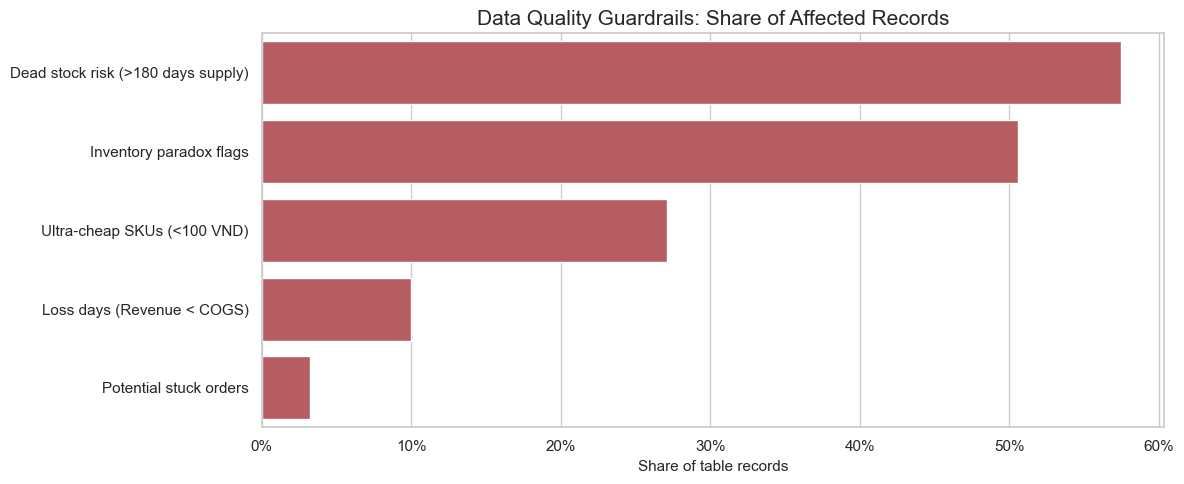

Saved figure: outputs\figures\fig0_data_quality_guardrails.png


,Issue,Records,Share,Business risk,Recommended handling
0,Ultra-cheap SKUs (<100 VND),654,0.271144,Có thể là lỗi đơn vị giá hoặc SKU thử nghiệm; ...,Flag để kiểm tra; không xóa tự động nếu chưa x...
1,Loss days (Revenue < COGS),382,0.099661,"Có thể phản ánh flash sale sâu, ghi nhận COGS ...",Flag riêng để phân tích ROI khuyến mãi và marg...
2,Inventory paradox flags,30495,0.506166,Stockout và overstock cùng xuất hiện có thể do...,Không bỏ; dùng như tín hiệu cần kiểm tra sâu h...
3,Dead stock risk (>180 days supply),34638,0.574933,"Vốn có thể bị chôn trong hàng bán chậm, gây áp...",Tách thành nhóm ưu tiên cho markdown/clearance...
4,Potential stuck orders,20852,0.032231,Có thể là đơn chưa hoàn tất hoặc pipeline xử l...,Segment riêng khi phân tích fulfillment hoặc c...


In [4]:
# Data Quality Guardrails

dq_records = []

# 1) Product price anomaly: ultra-cheap SKUs
ultra_cheap = products[products["price"] < 100].copy()
ultra_order_items = order_items[order_items["product_id"].isin(ultra_cheap["product_id"])]
dq_records.append({
    "Issue": "Ultra-cheap SKUs (<100 VND)",
    "Records": len(ultra_cheap),
    "Share": len(ultra_cheap) / len(products) if len(products) else np.nan,
    "Business risk": "Có thể là lỗi đơn vị giá hoặc SKU thử nghiệm; cần tách khỏi phân tích giá/margin.",
    "Recommended handling": "Flag để kiểm tra; không xóa tự động nếu chưa xác nhận business rule."
})

# 2) Loss days in sales
sales_quality = sales.copy()
sales_quality["gross_profit"] = sales_quality["Revenue"] - sales_quality["COGS"]
sales_quality["gross_margin"] = sales_quality["gross_profit"] / sales_quality["Revenue"].replace(0, np.nan)
loss_days = sales_quality[sales_quality["gross_profit"] < 0].copy()
dq_records.append({
    "Issue": "Loss days (Revenue < COGS)",
    "Records": len(loss_days),
    "Share": len(loss_days) / len(sales_quality) if len(sales_quality) else np.nan,
    "Business risk": "Có thể phản ánh flash sale sâu, ghi nhận COGS bất thường hoặc chiến lược xả hàng.",
    "Recommended handling": "Flag riêng để phân tích ROI khuyến mãi và margin, không gộp mù vào trung bình."
})

# 3) Inventory paradox: stockout and overstock at the same time
inventory_quality = inventory.copy()
inventory_quality["paradox_flag"] = (
    inventory_quality["stockout_flag"].fillna(0).astype(int).eq(1)
    & inventory_quality["overstock_flag"].fillna(0).astype(int).eq(1)
)
paradox = inventory_quality[inventory_quality["paradox_flag"]].copy()
dq_records.append({
    "Issue": "Inventory paradox flags",
    "Records": len(paradox),
    "Share": len(paradox) / len(inventory_quality) if len(inventory_quality) else np.nan,
    "Business risk": "Stockout và overstock cùng xuất hiện có thể do ngưỡng flag khác nhau hoặc misallocation ở SKU.",
    "Recommended handling": "Không bỏ; dùng như tín hiệu cần kiểm tra sâu hơn ở cấp SKU/category-segment."
})

# 4) Dead stock risk
dead_stock = inventory_quality[inventory_quality["days_of_supply"] > 180].copy()
dq_records.append({
    "Issue": "Dead stock risk (>180 days supply)",
    "Records": len(dead_stock),
    "Share": len(dead_stock) / len(inventory_quality) if len(inventory_quality) else np.nan,
    "Business risk": "Vốn có thể bị chôn trong hàng bán chậm, gây áp lực clearance/discount.",
    "Recommended handling": "Tách thành nhóm ưu tiên cho markdown/clearance và giảm nhập kỳ sau."
})

# 5) Stuck orders
orders_quality = orders.copy()
orders_quality["order_status_clean"] = orders_quality["order_status"].astype(str).str.lower().str.strip()
stuck_orders = orders_quality[orders_quality["order_status_clean"].isin(["created", "paid"])].copy()
dq_records.append({
    "Issue": "Potential stuck orders",
    "Records": len(stuck_orders),
    "Share": len(stuck_orders) / len(orders_quality) if len(orders_quality) else np.nan,
    "Business risk": "Có thể là đơn chưa hoàn tất hoặc pipeline xử lý bị kẹt; ảnh hưởng conversion/funnel analysis.",
    "Recommended handling": "Segment riêng khi phân tích fulfillment hoặc conversion."
})

dq_summary = pd.DataFrame(dq_records)

plt.figure(figsize=(12, 5))
sns.barplot(
    data=dq_summary.sort_values("Share", ascending=False),
    x="Share",
    y="Issue",
    color="#C44E52"
)
plt.title("Data Quality Guardrails: Share of Affected Records")
plt.xlabel("Share of table records")
plt.ylabel("")
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f"{x:.0%}"))
save_fig("fig0_data_quality_guardrails.png")

dq_summary


### Insight — Kiểm soát chất lượng dữ liệu trước khi diễn giải

**Phát hiện chính:** Dữ liệu có một số nhóm bản ghi cần được gắn cờ trước khi phân tích, bao gồm SKU có giá rất thấp, ngày có lợi nhuận gộp âm, tồn kho đồng thời xuất hiện `stockout_flag` và `overstock_flag`, dead stock theo `days_of_supply`, và các đơn hàng còn ở trạng thái `created` hoặc `paid`.

**Ý nghĩa kinh doanh:** Các điểm này không nhất thiết là lỗi dữ liệu cần loại bỏ ngay. Một số có thể phản ánh logic vận hành thực tế, chẳng hạn flash sale, clearance campaign, đơn hàng chưa hoàn tất hoặc các flag tồn kho được kích hoạt theo nhiều ngưỡng khác nhau. Tuy nhiên, nếu không được gắn cờ và diễn giải cẩn trọng, chúng có thể làm sai lệch nhận định về gross margin, hiệu quả khuyến mãi, rủi ro tồn kho và chất lượng chuyển đổi.

**Đề xuất hành động:** Giữ các bản ghi này trong dashboard nhưng phân tích chúng như các **analysis guardrails**. Khi viết report, cần ghi rõ rằng nhóm đã kiểm tra outlier, trạng thái đơn hàng và các business rule bất thường trước khi rút ra kết luận. Điều này giúp các insight về doanh thu, khuyến mãi, tồn kho và conversion có độ tin cậy cao hơn.

## 0. Master Analytical Table

Mục đích: tạo một bảng phân tích chính `line_items`, nối `order_items` với orders, customers, products, returns, reviews, promotions và shipments. Bảng này giúp các chart phía sau dùng cùng một logic doanh thu/lợi nhuận.

In [5]:
# Payment, shipment, return, review aggregates
payments_order = payments.groupby("order_id", as_index=False).agg(
    payment_value=("payment_value", "sum"),
    installments=("installments", "max"),
)

shipments_order = shipments.copy()
shipments_order["delivery_days"] = (shipments_order["delivery_date"] - shipments_order["ship_date"]).dt.days
shipments_order = shipments_order.groupby("order_id", as_index=False).agg(
    ship_date=("ship_date", "min"),
    delivery_date=("delivery_date", "max"),
    shipping_fee=("shipping_fee", "sum"),
    delivery_days=("delivery_days", "mean"),
)

returns_item = returns.groupby(["order_id", "product_id"], as_index=False).agg(
    return_records=("return_id", "count"),
    return_quantity=("return_quantity", "sum"),
    refund_amount=("refund_amount", "sum"),
)

reviews_item = reviews.groupby(["order_id", "product_id"], as_index=False).agg(
    avg_rating=("rating", "mean"),
    review_count=("review_id", "count"),
)

customer_geo = customers.merge(
    geography[["zip", "region", "district"]].drop_duplicates("zip"),
    on="zip",
    how="left",
)

orders_master = (
    orders
    .merge(customer_geo[["customer_id", "gender", "age_group", "acquisition_channel", "region", "district", "signup_date"]], on="customer_id", how="left")
    .merge(payments_order, on="order_id", how="left")
    .merge(shipments_order, on="order_id", how="left")
)

line_items = (
    order_items
    .merge(orders_master, on="order_id", how="left")
    .merge(products, on="product_id", how="left")
    .merge(returns_item, on=["order_id", "product_id"], how="left")
    .merge(reviews_item, on=["order_id", "product_id"], how="left")
    .merge(promotions[["promo_id", "promo_type", "promo_channel", "stackable_flag", "discount_value"]], on="promo_id", how="left")
)

line_items["gross_revenue"] = line_items["quantity"] * line_items["unit_price"]
line_items["net_revenue"] = line_items["gross_revenue"] - line_items["discount_amount"].fillna(0)
line_items["line_cogs"] = line_items["quantity"] * line_items["cogs"]
line_items["gross_profit"] = line_items["net_revenue"] - line_items["line_cogs"]
line_items["gross_margin"] = line_items["gross_profit"] / line_items["net_revenue"].replace(0, np.nan)
line_items["is_returned"] = line_items["return_records"].fillna(0).gt(0)
line_items["order_month"] = line_items["order_date"].dt.to_period("M").dt.to_timestamp()
line_items["order_year"] = line_items["order_date"].dt.year
line_items["promo_applied"] = line_items["promo_id"].notna()
line_items["discount_pct"] = (line_items["discount_amount"].fillna(0) / line_items["gross_revenue"].replace(0, np.nan)).clip(0, 1)

print("line_items shape:", line_items.shape)
line_items[["order_id", "product_id", "order_date", "category", "segment", "net_revenue", "gross_profit", "is_returned"]].head()

line_items shape: (714669, 52)


,order_id,product_id,order_date,category,segment,net_revenue,gross_profit,is_returned
0,1,2400,2012-07-04,GenZ,Trendy,7967.54,590.953941,False
1,2,609,2012-07-04,Streetwear,Everyday,71163.75,8249.820384,True
2,3,396,2012-07-04,Streetwear,Balanced,33660.99,3387.953233,False
3,4,635,2012-07-04,Streetwear,Everyday,53196.25,7169.097610,False
4,6,1935,2012-07-06,Outdoor,Activewear,1597.84,549.143643,False


# 1. Revenue & Seasonality

**Câu hỏi kinh doanh:** Doanh thu và lợi nhuận thay đổi như thế nào theo thời gian? Có mùa vụ theo tháng/ngày trong tuần không?

Đây là phần Descriptive nền tảng, đồng thời hỗ trợ Predictive vì seasonal pattern có thể dùng để lập kế hoạch tồn kho, logistics và campaign.

In [6]:
# KPI overview
kpi = pd.DataFrame({
    "KPI": [
        "Total Orders", "Total Customers", "Net Revenue", "Gross Profit",
        "Gross Margin", "Line Return Rate", "Order Cancel Rate", "Avg Review Rating"
    ],
    "Value": [
        f"{orders['order_id'].nunique():,.0f}",
        f"{customers['customer_id'].nunique():,.0f}",
        f"{line_items['net_revenue'].sum():,.0f}",
        f"{line_items['gross_profit'].sum():,.0f}",
        pct(line_items['gross_profit'].sum() / line_items['net_revenue'].sum()),
        pct(line_items['is_returned'].mean()),
        pct((orders['order_status'] == 'cancelled').mean()),
        f"{reviews['rating'].mean():.2f}",
    ]
})
kpi

,KPI,Value
0,Total Orders,"646,945"
1,Total Customers,"121,930"
2,Net Revenue,"15,680,869,265"
3,Gross Profit,"1,517,418,746"
4,Gross Margin,9.68%
5,Line Return Rate,5.59%
6,Order Cancel Rate,9.19%
7,Avg Review Rating,3.94


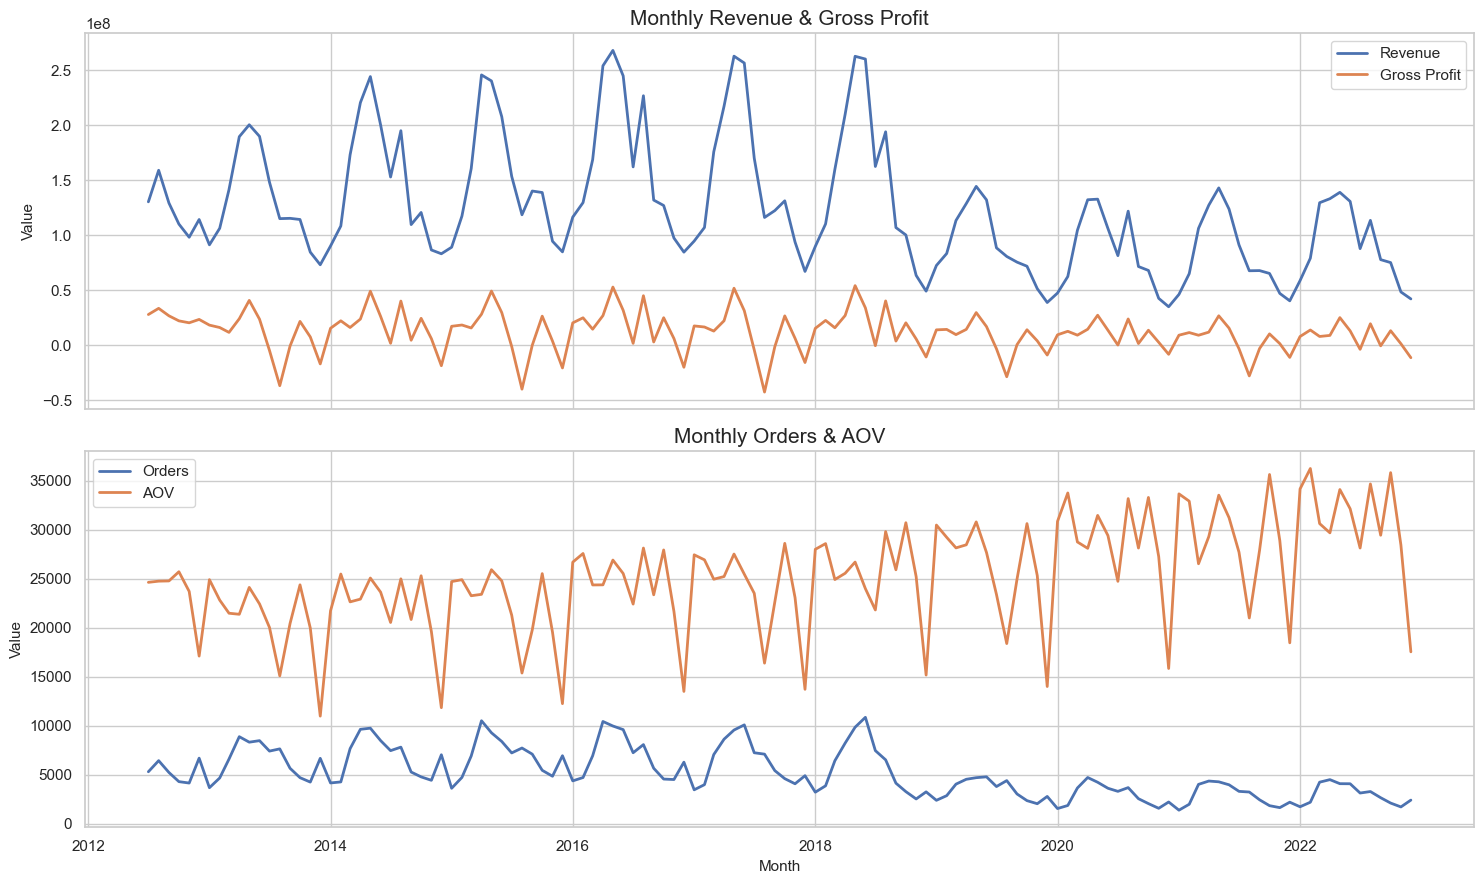

Saved figure: outputs\figures\fig1_revenue_profit_trend.png


,order_month,revenue,gross_profit,orders,aov,gross_margin
121,2022-08-01,1.135360e+08,1.950263e+07,3274,34678.071750,0.171775
122,2022-09-01,7.781686e+07,-5.783857e+05,2643,29442.624499,-0.007433
123,2022-10-01,7.513702e+07,1.316713e+07,2097,35830.719638,0.175242
124,2022-11-01,4.842012e+07,1.322094e+06,1703,28432.246418,0.027305
125,2022-12-01,4.208916e+07,-1.140051e+07,2400,17537.149921,-0.270866


In [7]:
# Chart 1A — Monthly revenue and gross profit trend
monthly = line_items.groupby("order_month", as_index=False).agg(
    revenue=("net_revenue", "sum"),
    gross_profit=("gross_profit", "sum"),
    orders=("order_id", "nunique"),
)
monthly["aov"] = monthly["revenue"] / monthly["orders"]
monthly["gross_margin"] = monthly["gross_profit"] / monthly["revenue"]

fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=True)
axes[0].plot(monthly["order_month"], monthly["revenue"], label="Revenue", linewidth=2)
axes[0].plot(monthly["order_month"], monthly["gross_profit"], label="Gross Profit", linewidth=2)
axes[0].set_title("Monthly Revenue & Gross Profit")
axes[0].set_ylabel("Value")
axes[0].legend()

axes[1].plot(monthly["order_month"], monthly["orders"], label="Orders", linewidth=2)
axes[1].plot(monthly["order_month"], monthly["aov"], label="AOV", linewidth=2)
axes[1].set_title("Monthly Orders & AOV")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Value")
axes[1].legend()

save_fig("fig1_revenue_profit_trend.png")
monthly.tail()

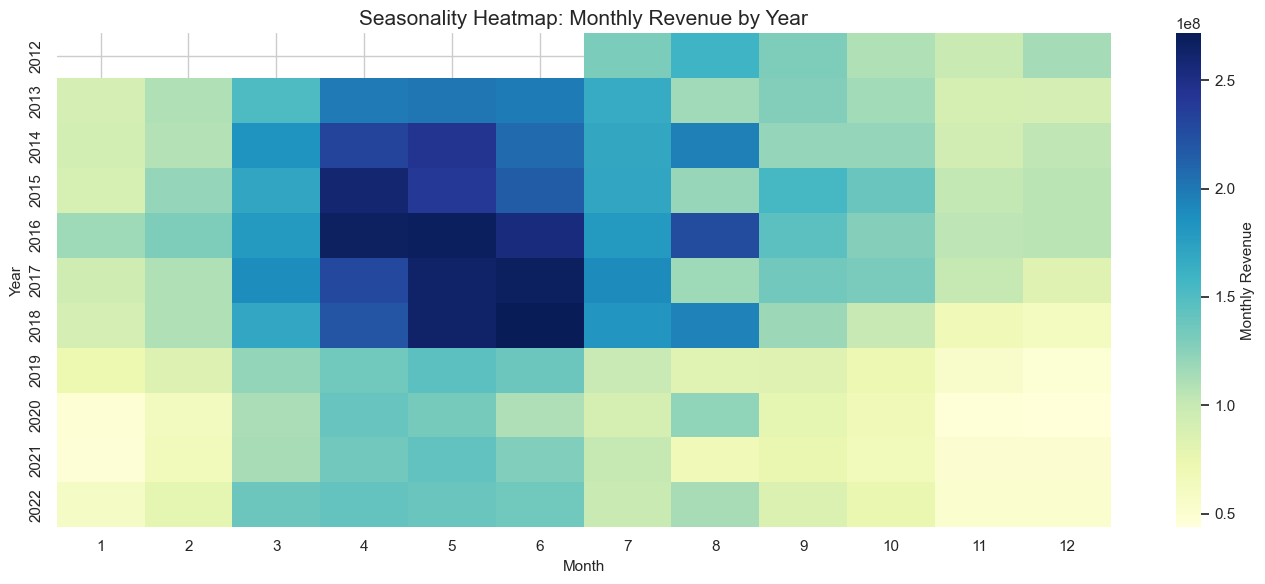

Saved figure: outputs\figures\fig2_revenue_seasonality_month_heatmap.png


In [8]:
# Chart 1B — Seasonality heatmap by year and month
sales_season = sales.copy()
sales_season["year"] = sales_season["Date"].dt.year
sales_season["month"] = sales_season["Date"].dt.month
monthly_sales = sales_season.groupby(["year", "month"], as_index=False).agg(revenue=("Revenue", "sum"))
heat = monthly_sales.pivot(index="year", columns="month", values="revenue")

plt.figure(figsize=(14, 6))
sns.heatmap(heat, cmap="YlGnBu", cbar_kws={"label": "Monthly Revenue"})
plt.title("Seasonality Heatmap: Monthly Revenue by Year")
plt.xlabel("Month")
plt.ylabel("Year")
save_fig("fig2_revenue_seasonality_month_heatmap.png")

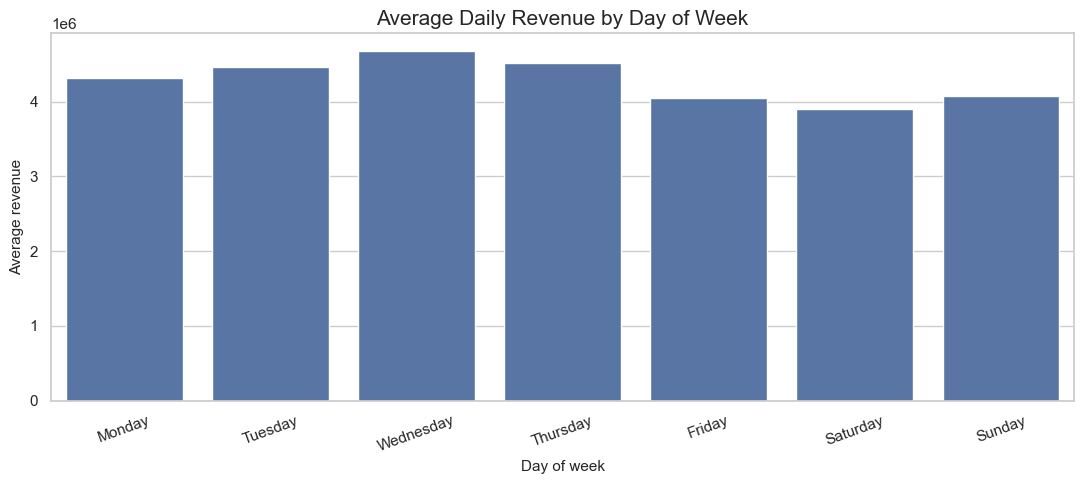

Saved figure: outputs\figures\fig3_day_of_week_seasonality.png


,day_of_week,avg_revenue
1,Monday,4.311035e+06
5,Tuesday,4.465103e+06
6,Wednesday,4.680065e+06
4,Thursday,4.523044e+06
0,Friday,4.046390e+06
2,Saturday,3.906581e+06
3,Sunday,4.073854e+06


In [9]:
# Chart 1C — Day-of-week seasonality
sales_dow = sales.copy()
sales_dow["day_of_week"] = sales_dow["Date"].dt.day_name()
sales_dow["month"] = sales_dow["Date"].dt.month

order_days = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
dow_summary = sales_dow.groupby("day_of_week", as_index=False).agg(avg_revenue=("Revenue", "mean"))
dow_summary["day_of_week"] = pd.Categorical(dow_summary["day_of_week"], categories=order_days, ordered=True)
dow_summary = dow_summary.sort_values("day_of_week")

plt.figure(figsize=(11, 5))
sns.barplot(data=dow_summary, x="day_of_week", y="avg_revenue", color="#4C72B0")
plt.title("Average Daily Revenue by Day of Week")
plt.xlabel("Day of week")
plt.ylabel("Average revenue")
plt.xticks(rotation=20)
save_fig("fig3_day_of_week_seasonality.png")
dow_summary

### Predictive Add-on — Seasonal Demand Index

Phần này bổ sung một góc nhìn **Predictive** rõ hơn: thay vì chỉ nhìn doanh thu đã xảy ra, ta chuẩn hóa doanh thu trung bình theo từng tháng thành **seasonal index**. Tháng có index > 1 nghĩa là nhu cầu lịch sử cao hơn mức trung bình; tháng có index < 1 nghĩa là nhu cầu thấp hơn mức trung bình. Chỉ số này có thể dùng làm tín hiệu lập kế hoạch trước cho tồn kho, logistics và campaign calendar.


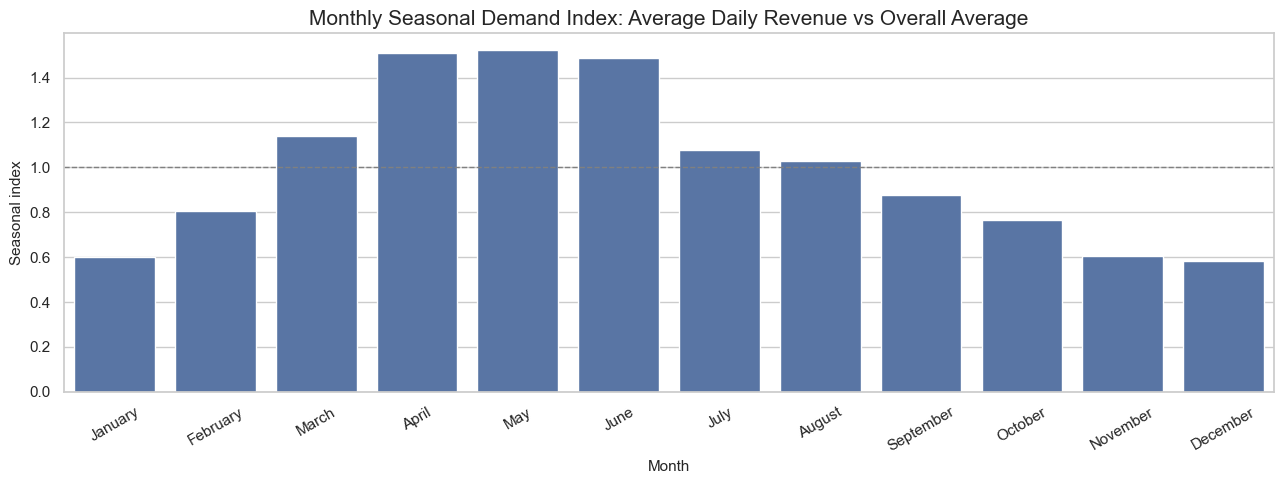

Saved figure: outputs\figures\fig3b_monthly_seasonal_demand_index.png


,month_name,avg_daily_revenue,seasonal_index
0,January,2.591155e+06,0.599425
1,February,3.480801e+06,0.805231
2,March,4.928185e+06,1.140062
3,April,6.532952e+06,1.511301
4,May,6.575416e+06,1.521125
5,June,6.427109e+06,1.486816
6,July,4.659789e+06,1.077973
7,August,4.441193e+06,1.027404
8,September,3.797826e+06,0.878570
9,October,3.302725e+06,0.764036


In [10]:
# Chart 1D — Monthly seasonal demand index
seasonal_index = sales.copy()
seasonal_index["month_num"] = seasonal_index["Date"].dt.month
seasonal_index["month_name"] = seasonal_index["Date"].dt.month_name()

month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

monthly_daily_avg = (
    seasonal_index
    .groupby(["month_num", "month_name"], as_index=False)
    .agg(avg_daily_revenue=("Revenue", "mean"))
    .sort_values("month_num")
)
monthly_daily_avg["seasonal_index"] = (
    monthly_daily_avg["avg_daily_revenue"] / monthly_daily_avg["avg_daily_revenue"].mean()
)
monthly_daily_avg["month_name"] = pd.Categorical(
    monthly_daily_avg["month_name"], categories=month_order, ordered=True
)

plt.figure(figsize=(13, 5))
sns.barplot(
    data=monthly_daily_avg,
    x="month_name",
    y="seasonal_index",
    color="#4C72B0"
)
plt.axhline(1.0, color="gray", linestyle="--", linewidth=1)
plt.title("Monthly Seasonal Demand Index: Average Daily Revenue vs Overall Average")
plt.xlabel("Month")
plt.ylabel("Seasonal index")
plt.xticks(rotation=30)
save_fig("fig3b_monthly_seasonal_demand_index.png")
monthly_daily_avg[["month_name", "avg_daily_revenue", "seasonal_index"]]


### Insight — Chỉ số mùa vụ để dự báo nhu cầu

**Phát hiện chính:** Chỉ số mùa vụ cho thấy doanh thu/ngày không phân bổ đều giữa các tháng, mà có những tháng thường cao hơn hoặc thấp hơn mức trung bình lịch sử. So với heatmap, chỉ số này giúp lượng hóa mức độ mạnh/yếu của nhu cầu theo tháng, từ đó dễ so sánh và sử dụng cho lập kế hoạch.

**Ý nghĩa kinh doanh:** Đây là một insight mang tính Predictive vì pattern mùa vụ trong quá khứ có thể được dùng như tín hiệu dự báo nhu cầu tương lai. Nếu doanh nghiệp nhận diện được các tháng có nhu cầu cao trước khi peak season xảy ra, doanh nghiệp có thể chủ động chuẩn bị tồn kho, nhân sự kho vận, ngân sách marketing và lịch khuyến mãi thay vì phản ứng muộn.

**Đề xuất hành động:** Sử dụng chỉ số mùa vụ như một đầu vào cho demand planning. Các tháng có nhu cầu cao hơn trung bình nên được ưu tiên tăng tồn kho an toàn, kiểm tra năng lực giao hàng và lên lịch campaign sớm. Các tháng thấp điểm có thể được dùng để chạy chiến dịch kích cầu, clearance hoặc bundle nhằm cải thiện vòng quay tồn kho và giảm áp lực lưu kho.

### Diagnostic Add-on — So sánh sức khỏe kinh doanh trước và sau 2019

Phần này phân tích điểm gãy tăng trưởng quanh năm 2019 bằng cách so sánh các chỉ số kinh doanh cốt lõi trước và sau giai đoạn này. Thay vì chỉ nhìn doanh thu tổng, phân tích tách bức tranh kinh doanh thành nhiều driver: doanh thu, số đơn hàng, số khách hàng, AOV, gross profit và gross margin.

Mục tiêu là xác định doanh nghiệp suy yếu ở đâu: nhu cầu thị trường, quy mô khách hàng, tần suất/khối lượng đơn hàng, giá trị đơn trung bình hay chất lượng lợi nhuận.

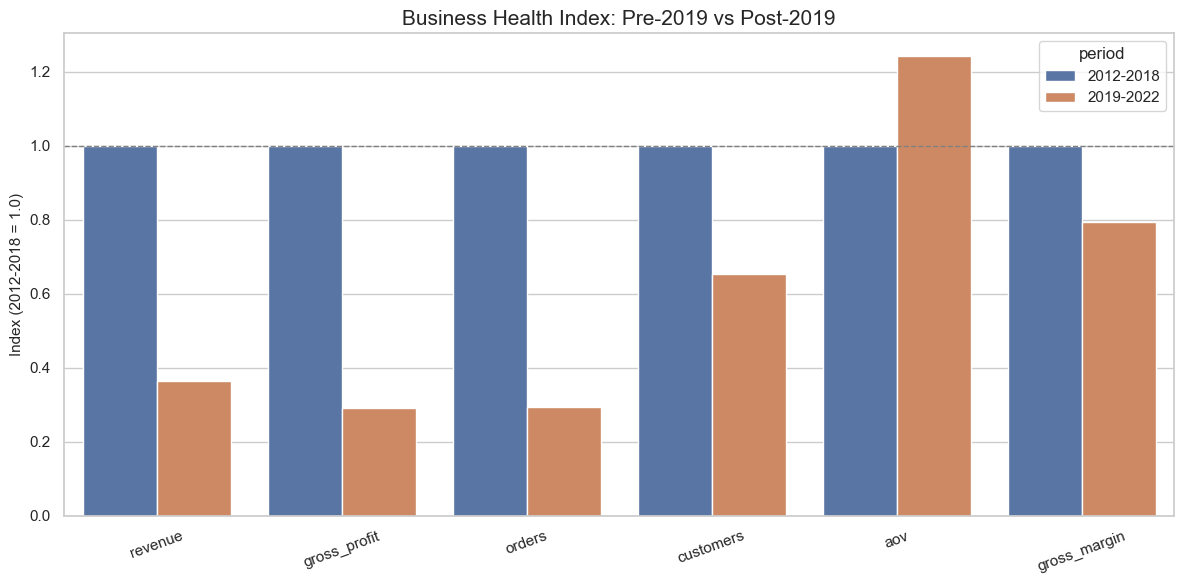

Saved figure: outputs\figures\fig3c_pre_post_2019_business_health_index.png


,period,revenue,gross_profit,orders,customers,aov,gross_margin
0,2012-2018,1.148665e+10,1.176038e+09,499934,84186,22976.332631,0.102383
1,2019-2022,4.194219e+09,3.413811e+08,147011,55039,28529.969783,0.081393


In [11]:
# Chart 1E — Business health before vs after 2019
period_items = line_items.copy()
period_items["period"] = np.where(period_items["order_year"] <= 2018, "2012-2018", "2019-2022")

period_summary = (
    period_items.groupby("period", as_index=False)
    .agg(
        revenue=("net_revenue", "sum"),
        gross_profit=("gross_profit", "sum"),
        orders=("order_id", "nunique"),
        customers=("customer_id", "nunique"),
    )
)
period_summary["aov"] = period_summary["revenue"] / period_summary["orders"]
period_summary["gross_margin"] = period_summary["gross_profit"] / period_summary["revenue"]

# Normalize to pre-2019 = 1.0 where possible
base = period_summary[period_summary["period"] == "2012-2018"].iloc[0]
metrics = ["revenue", "gross_profit", "orders", "customers", "aov", "gross_margin"]
period_index = period_summary.copy()
for m in metrics:
    period_index[m + "_index"] = period_index[m] / base[m] if base[m] != 0 else np.nan

plot_df = period_index.melt(
    id_vars="period",
    value_vars=[m + "_index" for m in metrics],
    var_name="Metric",
    value_name="Index"
)
plot_df["Metric"] = plot_df["Metric"].str.replace("_index", "", regex=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=plot_df, x="Metric", y="Index", hue="period")
plt.axhline(1.0, color="gray", linestyle="--", linewidth=1)
plt.title("Business Health Index: Pre-2019 vs Post-2019")
plt.xlabel("")
plt.ylabel("Index (2012-2018 = 1.0)")
plt.xticks(rotation=20)
save_fig("fig3c_pre_post_2019_business_health_index.png")

period_summary


### Insight — Điểm gãy tăng trưởng sau 2019

**Phát hiện chính:** So sánh trước và sau 2019 cho thấy sức khỏe kinh doanh cần được nhìn qua nhiều driver, không chỉ qua doanh thu. Khi phân rã theo số đơn hàng, số khách hàng, AOV, gross profit và gross margin, dashboard giúp xác định liệu sự suy yếu đến từ nhu cầu, customer base, order volume hay chất lượng lợi nhuận.

**Ý nghĩa kinh doanh:** Nếu doanh thu yếu đi chủ yếu do số đơn hoặc số khách giảm, vấn đề trọng tâm nằm ở acquisition, retention hoặc conversion. Nếu AOV vẫn ổn nhưng gross margin giảm, rủi ro có thể đến từ discount quá sâu, mix sản phẩm kém hiệu quả hoặc COGS tăng. Nếu gross profit giảm mạnh hơn revenue, doanh nghiệp đang đối mặt với tăng trưởng kém chất lượng: bán được hàng nhưng không giữ được lợi nhuận tương ứng.

**Đề xuất hành động:** Sử dụng phân rã trước/sau 2019 như một framework chẩn đoán trong report. Thay vì chỉ đặt câu hỏi “doanh thu tăng hay giảm”, cần xác định driver nào làm doanh nghiệp yếu đi và driver nào còn khả năng phục hồi. Từ đó, chiến lược nên được tách rõ: cải thiện acquisition/retention nếu vấn đề nằm ở khách hàng, tối ưu promotion/product mix nếu vấn đề nằm ở margin, và kiểm soát chi phí nếu gross profit suy giảm.

### Insight — Doanh thu và tính mùa vụ

**Phát hiện chính:** Doanh thu không phân bổ đều theo thời gian mà có dấu hiệu mùa vụ theo tháng và theo ngày trong tuần. Một số giai đoạn ghi nhận doanh thu cao hơn rõ rệt, cho thấy nhu cầu của khách hàng có tính chu kỳ thay vì ổn định hoàn toàn qua thời gian.

**Ý nghĩa kinh doanh:** Mùa vụ là tín hiệu quan trọng cho cả forecasting và vận hành. Nếu doanh nghiệp chỉ phản ứng sau khi nhu cầu đã tăng, rủi ro thiếu hàng, quá tải kho vận và giao hàng chậm sẽ cao hơn. Ngược lại, nhận diện được các giai đoạn cao điểm từ dữ liệu lịch sử giúp doanh nghiệp chuẩn bị trước về tồn kho, nhân sự, logistics và ngân sách marketing.

**Đề xuất hành động:** Doanh nghiệp nên đưa pattern mùa vụ vào kế hoạch demand planning và campaign calendar. Các giai đoạn có xu hướng doanh thu cao nên được chuẩn bị tồn kho và năng lực giao hàng sớm hơn; các chiến dịch flash sale, email marketing hoặc push notification nên được ưu tiên vào thời điểm có nhu cầu tự nhiên cao. Với giai đoạn thấp điểm, doanh nghiệp có thể chạy kích cầu, bundle hoặc clearance campaign để cải thiện vòng quay hàng tồn.

# 2. Customer & Retention

**Câu hỏi kinh doanh:** Tăng trưởng đến từ khách mới hay khách quay lại? Kênh acquisition nào đem lại khách chất lượng hơn?

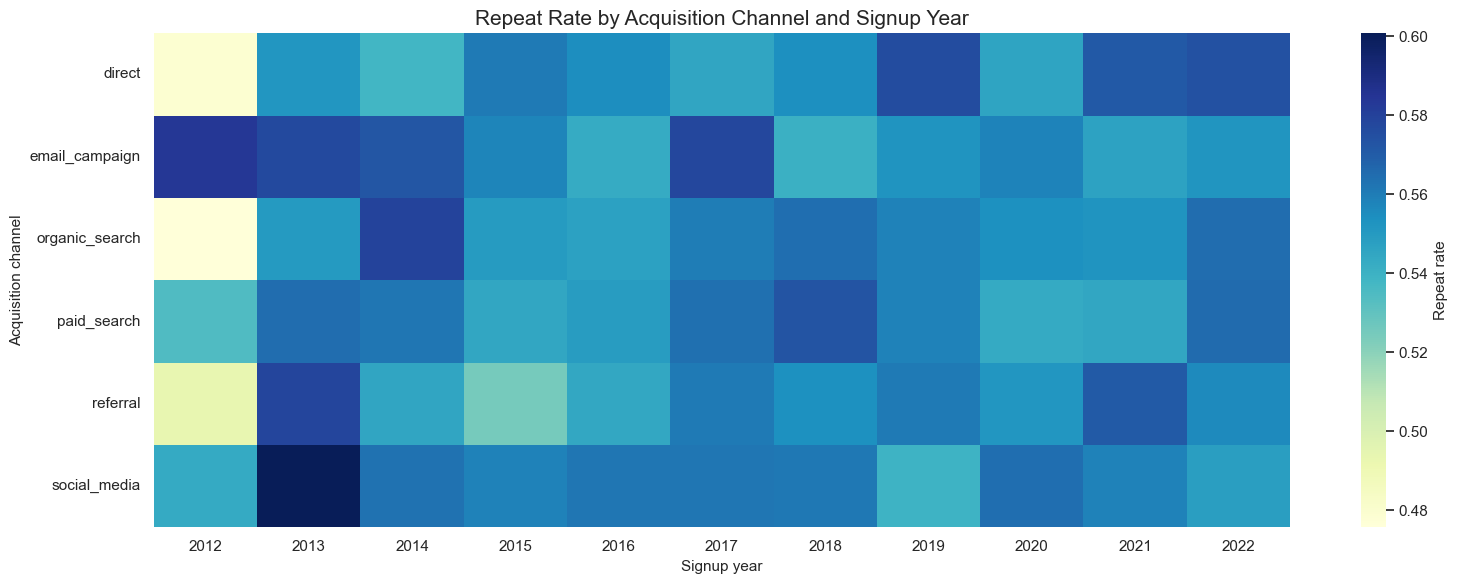

Saved figure: outputs\figures\fig4_repeat_rate_cohort_heatmap.png


,signup_year,acquisition_channel,customers,avg_orders,repeat_rate
11,2013,social_media,591,5.759729,0.600677
9,2013,paid_search,586,5.653584,0.564846
12,2014,direct,394,5.616751,0.538071
14,2014,organic_search,1532,5.577023,0.579634
10,2013,referral,306,5.562092,0.578431
49,2020,email_campaign,2086,5.539789,0.558006
17,2014,social_media,985,5.537056,0.563452
36,2018,direct,1043,5.523490,0.554171
3,2012,paid_search,189,5.492063,0.534392
44,2019,organic_search,4452,5.458446,0.558401


In [12]:
# Chart 2A — Repeat rate by acquisition channel and signup year
cust_orders = orders.groupby("customer_id", as_index=False).agg(
    total_orders=("order_id", "nunique"),
    first_order=("order_date", "min"),
    last_order=("order_date", "max"),
)

cohort = customers[["customer_id", "signup_date", "acquisition_channel", "age_group"]].merge(cust_orders, on="customer_id", how="left")
cohort["total_orders"] = cohort["total_orders"].fillna(0)
cohort["is_repeat"] = cohort["total_orders"] > 1
cohort["signup_year"] = cohort["signup_date"].dt.year

cohort_summary = cohort.groupby(["signup_year", "acquisition_channel"], as_index=False).agg(
    customers=("customer_id", "nunique"),
    avg_orders=("total_orders", "mean"),
    repeat_rate=("is_repeat", "mean"),
)

pivot_repeat = cohort_summary.pivot(index="acquisition_channel", columns="signup_year", values="repeat_rate")

plt.figure(figsize=(16, 6))
sns.heatmap(pivot_repeat, cmap="YlGnBu", cbar_kws={"label": "Repeat rate"})
plt.title("Repeat Rate by Acquisition Channel and Signup Year")
plt.xlabel("Signup year")
plt.ylabel("Acquisition channel")
save_fig("fig4_repeat_rate_cohort_heatmap.png")
cohort_summary.sort_values("avg_orders", ascending=False).head(10)

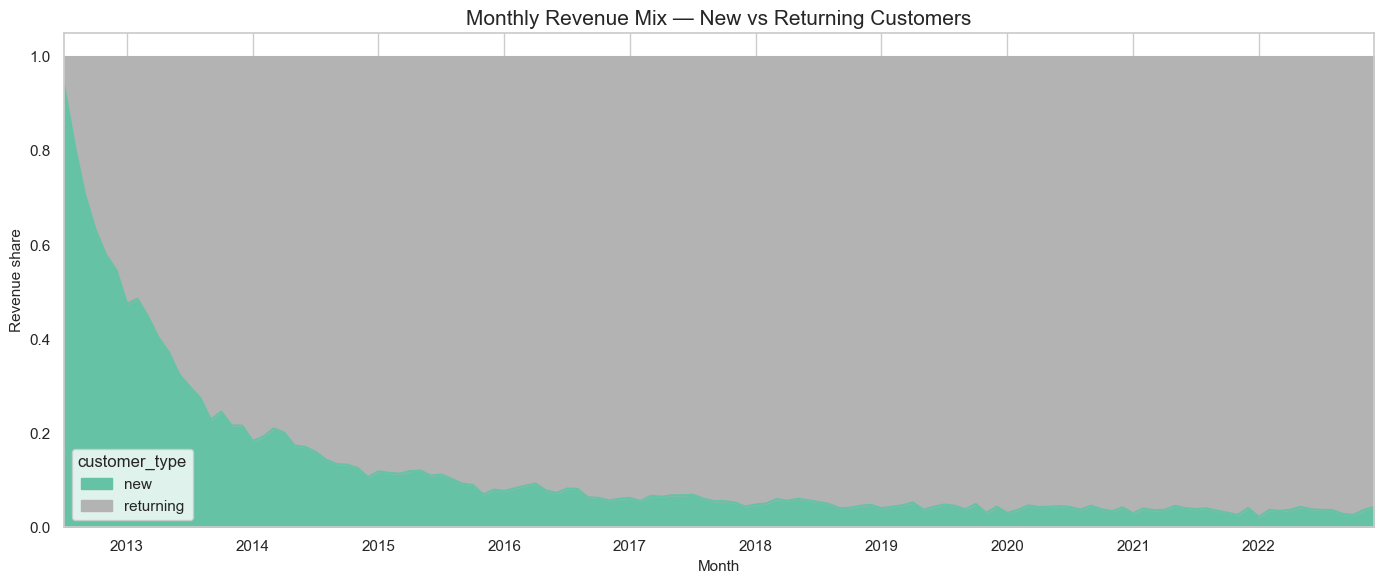

Saved figure: outputs\figures\fig5_new_vs_returning_revenue_mix.png


customer_type,new,returning
order_month,,
2022-01-01,0.022122,0.977878
2022-02-01,0.037016,0.962984
2022-03-01,0.034402,0.965598
2022-04-01,0.037228,0.962772
2022-05-01,0.043420,0.956580
2022-06-01,0.038361,0.961639
2022-07-01,0.037092,0.962908
2022-08-01,0.036723,0.963277
2022-09-01,0.028544,0.971456


In [13]:
# Chart 2B — Monthly revenue mix: new vs returning customers
first_order_date = orders.groupby("customer_id", as_index=False)["order_date"].min().rename(columns={"order_date": "first_order_date"})
ord_type = orders[["order_id", "customer_id", "order_date"]].merge(first_order_date, on="customer_id", how="left")
ord_type["customer_type"] = np.where(ord_type["order_date"] == ord_type["first_order_date"], "new", "returning")

mix = line_items[["order_id", "order_month", "net_revenue"]].merge(ord_type[["order_id", "customer_type"]], on="order_id", how="left")
mix_m = mix.groupby(["order_month", "customer_type"], as_index=False)["net_revenue"].sum()
pivot_mix = mix_m.pivot(index="order_month", columns="customer_type", values="net_revenue").fillna(0)
pivot_share = pivot_mix.div(pivot_mix.sum(axis=1), axis=0)

pivot_share.plot(kind="area", stacked=True, figsize=(14, 6), colormap="Set2")
plt.title("Monthly Revenue Mix — New vs Returning Customers")
plt.xlabel("Month")
plt.ylabel("Revenue share")
save_fig("fig5_new_vs_returning_revenue_mix.png")
pivot_share.tail(12)

### Diagnostic Add-on — Repeat purchase trước và sau 2019

Phần này phân tích khả năng mua lại của khách hàng trước và sau năm 2019 thông qua hai chỉ số: **repeat rate** và **số đơn trung bình mỗi khách hàng**. Mục tiêu là đánh giá liệu tăng trưởng doanh thu có được hỗ trợ bởi hành vi mua lặp lại hay doanh nghiệp đang phụ thuộc quá nhiều vào việc liên tục thu hút khách hàng mới.

Repeat purchase là một chỉ báo quan trọng về chất lượng tăng trưởng, vì khách hàng quay lại thường phản ánh mức độ hài lòng, niềm tin với thương hiệu và hiệu quả của trải nghiệm sau mua.

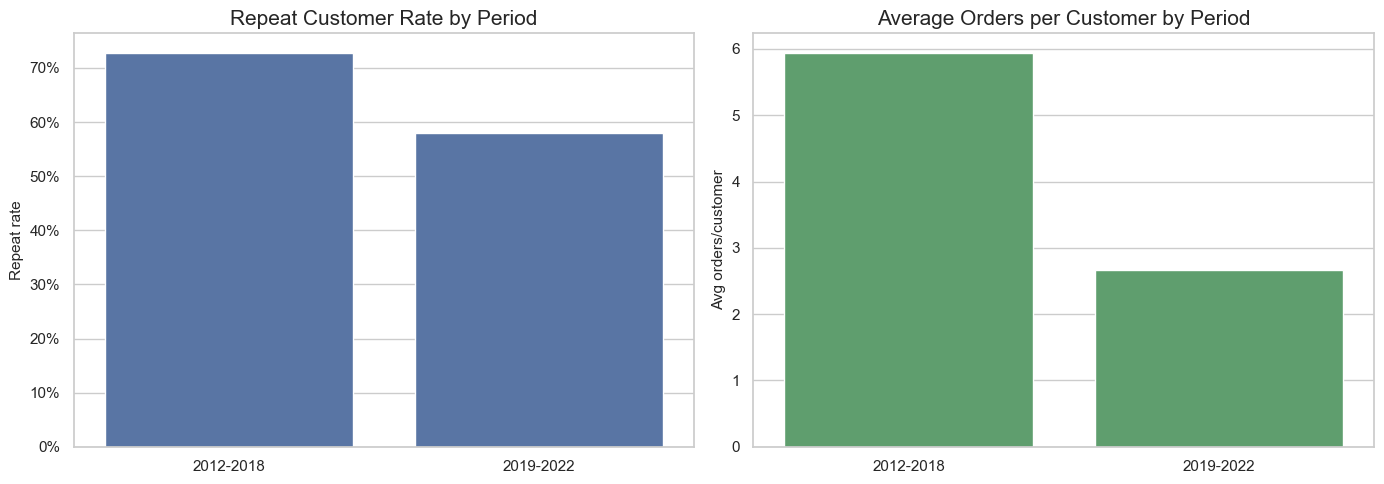

Saved figure: outputs\figures\fig5b_pre_post_repeat_purchase_diagnostic.png


,period,customers,repeat_rate,avg_orders_per_customer
0,2012-2018,84186,0.727508,5.938446
1,2019-2022,55039,0.579462,2.671033


In [14]:
# Chart 2C — Pre/Post-2019 repeat purchase diagnostic
orders_period = orders.copy()
orders_period["year"] = orders_period["order_date"].dt.year
orders_period["period"] = np.where(orders_period["year"] <= 2018, "2012-2018", "2019-2022")

cust_period_orders = (
    orders_period.groupby(["period", "customer_id"], as_index=False)
    .agg(orders_per_customer=("order_id", "nunique"))
)
cust_period_orders["is_repeat_customer"] = cust_period_orders["orders_per_customer"] > 1

repeat_period = (
    cust_period_orders.groupby("period", as_index=False)
    .agg(
        customers=("customer_id", "nunique"),
        repeat_rate=("is_repeat_customer", "mean"),
        avg_orders_per_customer=("orders_per_customer", "mean"),
    )
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=repeat_period, x="period", y="repeat_rate", ax=axes[0], color="#4C72B0")
axes[0].set_title("Repeat Customer Rate by Period")
axes[0].set_xlabel("")
axes[0].set_ylabel("Repeat rate")
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f"{x:.0%}"))

sns.barplot(data=repeat_period, x="period", y="avg_orders_per_customer", ax=axes[1], color="#55A868")
axes[1].set_title("Average Orders per Customer by Period")
axes[1].set_xlabel("")
axes[1].set_ylabel("Avg orders/customer")

save_fig("fig5b_pre_post_repeat_purchase_diagnostic.png")
repeat_period


### Insight — Retention là driver của chất lượng tăng trưởng

**Phát hiện chính:** Repeat rate và số đơn trung bình mỗi khách hàng cho biết doanh nghiệp có đang xây dựng được hành vi mua lặp lại hay không. Nếu các chỉ số này suy yếu sau 2019, vấn đề không thể được giải thích chỉ bằng biến động traffic hoặc acquisition, mà còn liên quan trực tiếp đến khả năng giữ chân khách hàng.

**Ý nghĩa kinh doanh:** Acquisition có thể tạo đơn hàng ngắn hạn, nhưng retention mới quyết định chất lượng tăng trưởng dài hạn. Khi khách mua một lần không quay lại, doanh nghiệp phải liên tục chi thêm ngân sách để thay thế khách hàng đã mất. Điều này làm chi phí tăng trưởng cao hơn và khiến doanh thu kém bền vững hơn, đặc biệt trong ngành thời trang thương mại điện tử nơi hành vi mua lặp lại có vai trò lớn.

**Đề xuất hành động:** Doanh nghiệp nên xem CRM, loyalty program, email remarketing, win-back campaign và personalized recommendation là các đòn bẩy tăng trưởng chính, không chỉ là hoạt động hỗ trợ marketing. Hiệu quả acquisition cũng nên được đánh giá theo chất lượng khách hàng sau lần mua đầu tiên, bao gồm tỷ lệ quay lại mua hàng, số đơn trung bình mỗi khách và doanh thu từ khách hàng returning.

**Caption — Revenue mix theo khách mới và khách quay lại:** Biểu đồ này giúp kiểm tra doanh thu đang đến từ acquisition hay retention. Nếu tỷ trọng doanh thu từ khách hàng quay lại suy yếu, doanh nghiệp cần ưu tiên các hoạt động giữ chân và kích hoạt mua lại thay vì chỉ mở rộng ngân sách kéo traffic mới.


# 3. Product Portfolio & Profitability

**Câu hỏi kinh doanh:** Doanh thu đang phụ thuộc vào nhóm sản phẩm nào? Nhóm nào có doanh thu cao nhưng margin/return risk xấu?

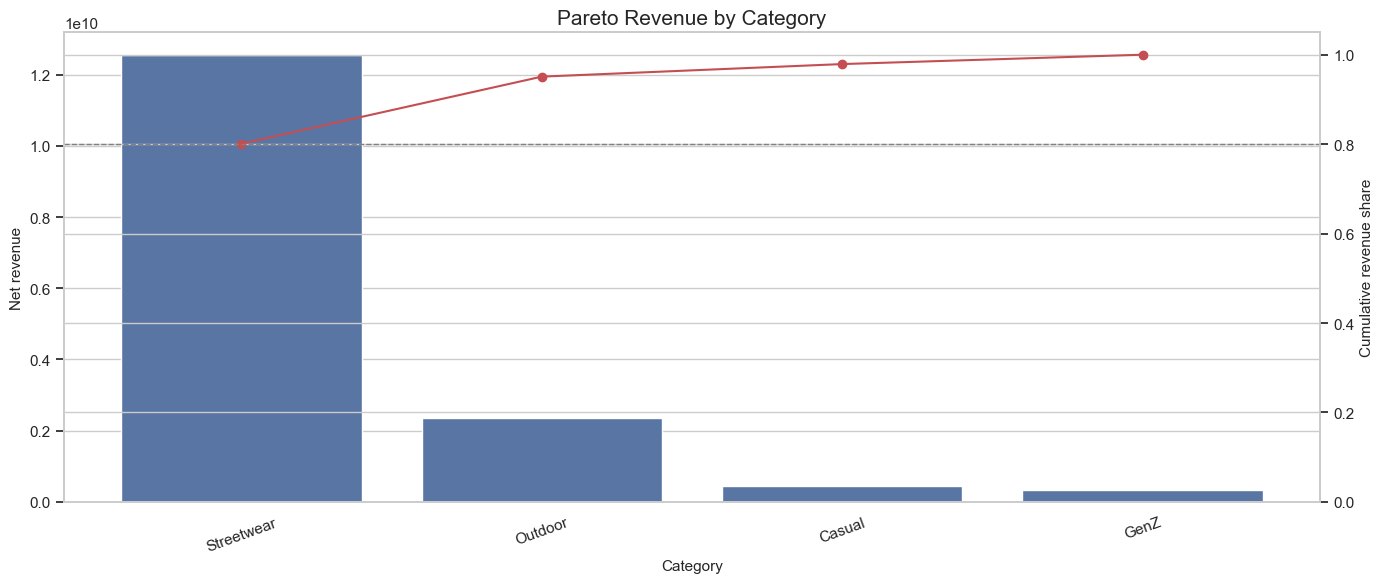

Saved figure: outputs\figures\fig6_category_revenue_pareto.png


,category,revenue,cum_share
3,Streetwear,1.255848e+10,0.800879
2,Outdoor,2.353397e+09,0.950960
0,Casual,4.402852e+08,0.979038
1,GenZ,3.287102e+08,1.000000


In [15]:
# Chart 3A — Pareto revenue by category
cat_rev = line_items.groupby("category", as_index=False).agg(revenue=("net_revenue", "sum")).sort_values("revenue", ascending=False)
cat_rev["cum_share"] = cat_rev["revenue"].cumsum() / cat_rev["revenue"].sum()

fig, ax1 = plt.subplots(figsize=(14, 6))
sns.barplot(data=cat_rev, x="category", y="revenue", ax=ax1, color="#4C72B0")
ax1.set_title("Pareto Revenue by Category")
ax1.set_xlabel("Category")
ax1.set_ylabel("Net revenue")
ax1.tick_params(axis="x", rotation=20)

ax2 = ax1.twinx()
ax2.plot(range(len(cat_rev)), cat_rev["cum_share"], color="#C44E52", marker="o")
ax2.axhline(0.8, color="gray", linestyle="--", linewidth=1)
ax2.set_ylabel("Cumulative revenue share")
ax2.set_ylim(0, 1.05)

save_fig("fig6_category_revenue_pareto.png")
cat_rev

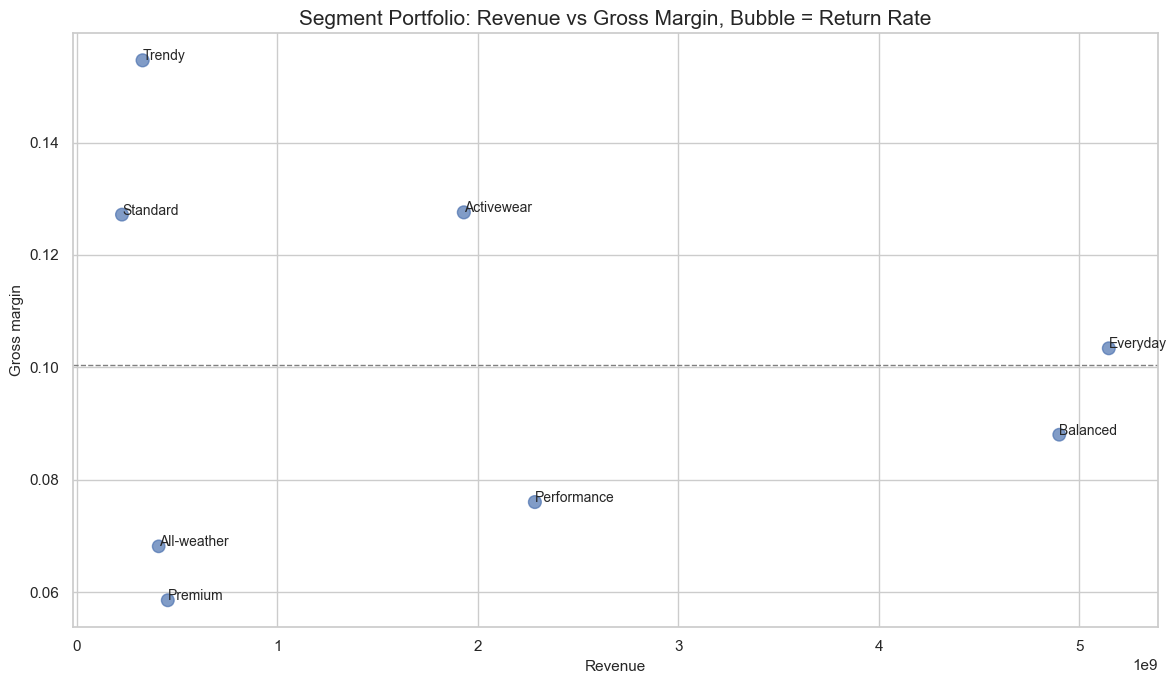

Saved figure: outputs\figures\fig7_segment_portfolio_map.png


,segment,revenue,gross_profit,return_rate,gross_margin
3,Everyday,5.147455e+09,5.321748e+08,0.055568,0.103386
2,Balanced,4.900318e+09,4.312361e+08,0.054320,0.088002
4,Performance,2.285029e+09,1.736938e+08,0.056260,0.076014
0,Activewear,1.930705e+09,2.463395e+08,0.056799,0.127590
5,Premium,4.542119e+08,2.658623e+07,0.055491,0.058533
1,All-weather,4.087651e+08,2.784908e+07,0.053478,0.068130
7,Trendy,3.287102e+08,5.083638e+07,0.057214,0.154654
6,Standard,2.256749e+08,2.870285e+07,0.054951,0.127187


In [16]:
# Chart 3B — Segment portfolio map: revenue vs gross margin, bubble = return rate
seg_perf = line_items.groupby("segment", as_index=False).agg(
    revenue=("net_revenue", "sum"),
    gross_profit=("gross_profit", "sum"),
    return_rate=("is_returned", "mean")
)
seg_perf["gross_margin"] = seg_perf["gross_profit"] / seg_perf["revenue"]

plt.figure(figsize=(12, 7))
plt.scatter(seg_perf["revenue"], seg_perf["gross_margin"], s=1500 * seg_perf["return_rate"], alpha=0.7)
for _, r in seg_perf.iterrows():
    plt.annotate(r["segment"], (r["revenue"], r["gross_margin"]), fontsize=10)

plt.title("Segment Portfolio: Revenue vs Gross Margin, Bubble = Return Rate")
plt.xlabel("Revenue")
plt.ylabel("Gross margin")
plt.axhline(seg_perf["gross_margin"].mean(), color="gray", linestyle="--", linewidth=1)
save_fig("fig7_segment_portfolio_map.png")
seg_perf.sort_values("revenue", ascending=False)

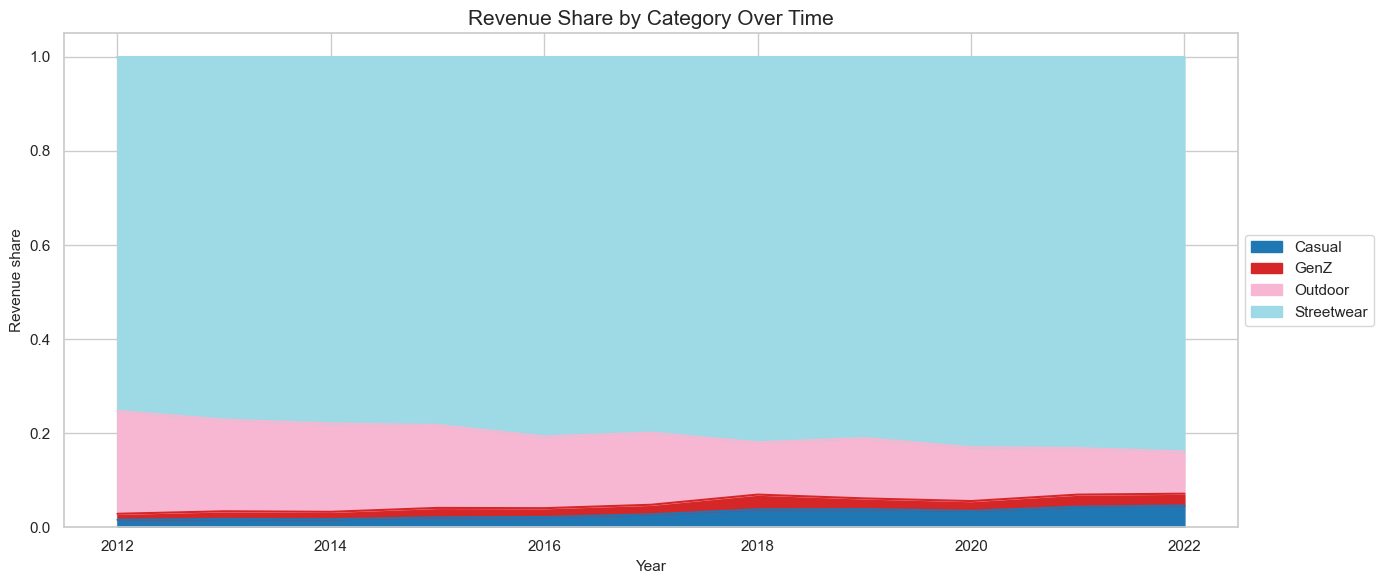

Saved figure: outputs\figures\fig8_category_revenue_share_over_time.png


category,Casual,GenZ,Outdoor,Streetwear
order_year,,,,
2018,0.038114,0.031322,0.111365,0.819199
2019,0.038539,0.022775,0.128311,0.810374
2020,0.034830,0.020844,0.114326,0.830000
2021,0.043767,0.025622,0.099053,0.831558
2022,0.046213,0.025192,0.089561,0.839035


In [17]:
# Chart 3C — Revenue share by category over years
cat_year = line_items.groupby(["order_year", "category"], as_index=False).agg(revenue=("net_revenue", "sum"))
cat_year_pivot = cat_year.pivot(index="order_year", columns="category", values="revenue").fillna(0)
cat_year_share = cat_year_pivot.div(cat_year_pivot.sum(axis=1), axis=0)

cat_year_share.plot(kind="area", stacked=True, figsize=(14, 6), colormap="tab20")
plt.title("Revenue Share by Category Over Time")
plt.xlabel("Year")
plt.ylabel("Revenue share")
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))
save_fig("fig8_category_revenue_share_over_time.png")
cat_year_share.tail()

### Insight — Danh mục sản phẩm và rủi ro phụ thuộc doanh thu

**Phát hiện chính:** Doanh thu có xu hướng tập trung vào một số ít category hoặc segment chủ lực. Điều này giúp doanh nghiệp xác định rõ các nhóm sản phẩm đang tạo doanh thu chính, nhưng đồng thời cũng tạo ra rủi ro phụ thuộc danh mục nếu các nhóm này gặp vấn đề về nhu cầu, tồn kho, biên lợi nhuận hoặc tỷ lệ trả hàng.

**Ý nghĩa kinh doanh:** Một category có doanh thu cao chưa chắc là category nên được ưu tiên tuyệt đối. Nếu nhóm đó có gross margin thấp, return risk cao hoặc overstock lớn, việc tiếp tục đẩy marketing và tồn kho có thể làm tăng doanh thu ngắn hạn nhưng không cải thiện lợi nhuận thực sự. Ngược lại, một số nhóm có doanh thu hiện tại chưa quá lớn nhưng biên lợi nhuận tốt và rủi ro trả hàng thấp có thể là cơ hội tăng trưởng chất lượng hơn.

**Đề xuất hành động:** Doanh nghiệp nên ưu tiên sản phẩm dựa trên bốn tiêu chí cùng lúc: doanh thu cao, biên lợi nhuận tốt, tỷ lệ trả hàng thấp và tồn kho vận hành ổn định. Nhóm có doanh thu cao và margin tốt nên được tăng tồn kho, tăng hiển thị và ưu tiên marketing. Nhóm có margin thấp, tồn kho dư hoặc return risk cao nên được kiểm soát nhập hàng, tối ưu mô tả sản phẩm hoặc xử lý bằng clearance campaign thay vì tiếp tục mở rộng đại trà.

# 4. Promotion Effectiveness

**Câu hỏi kinh doanh:** Khuyến mãi có giúp tăng hiệu quả hay chỉ làm giảm margin?

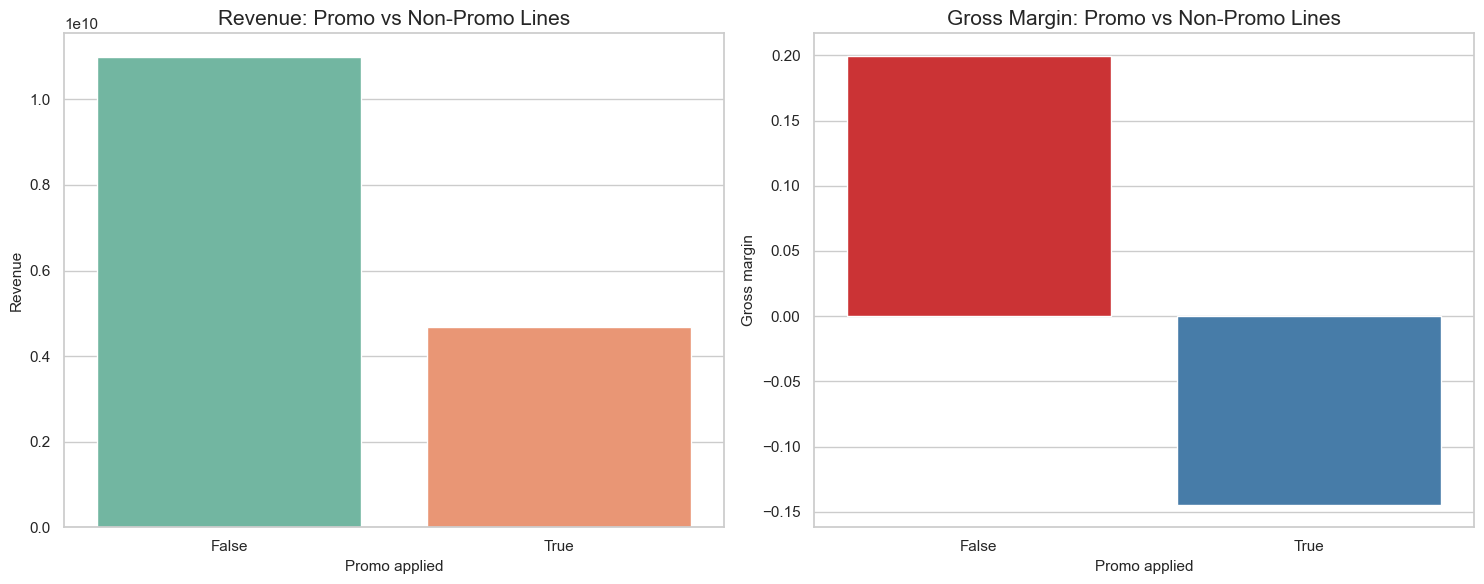

Saved figure: outputs\figures\fig9_promo_vs_nonpromo.png


,promo_applied,lines,revenue,gross_profit,avg_discount,return_rate,gross_margin
0,False,438353,1.099504e+10,2.195015e+09,0.00000,0.055898,0.199637
1,True,276316,4.685830e+09,-6.775966e+08,2712.86252,0.055864,-0.144605


In [18]:
# Chart 4A — Promo vs non-promo lines
promo_analysis = line_items.groupby("promo_applied", as_index=False).agg(
    lines=("order_id", "count"),
    revenue=("net_revenue", "sum"),
    gross_profit=("gross_profit", "sum"),
    avg_discount=("discount_amount", "mean"),
    return_rate=("is_returned", "mean"),
)
promo_analysis["gross_margin"] = promo_analysis["gross_profit"] / promo_analysis["revenue"]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.barplot(data=promo_analysis, x="promo_applied", y="revenue", ax=axes[0], palette="Set2")
axes[0].set_title("Revenue: Promo vs Non-Promo Lines")
axes[0].set_xlabel("Promo applied")
axes[0].set_ylabel("Revenue")

sns.barplot(data=promo_analysis, x="promo_applied", y="gross_margin", ax=axes[1], palette="Set1")
axes[1].set_title("Gross Margin: Promo vs Non-Promo Lines")
axes[1].set_xlabel("Promo applied")
axes[1].set_ylabel("Gross margin")

save_fig("fig9_promo_vs_nonpromo.png")
promo_analysis

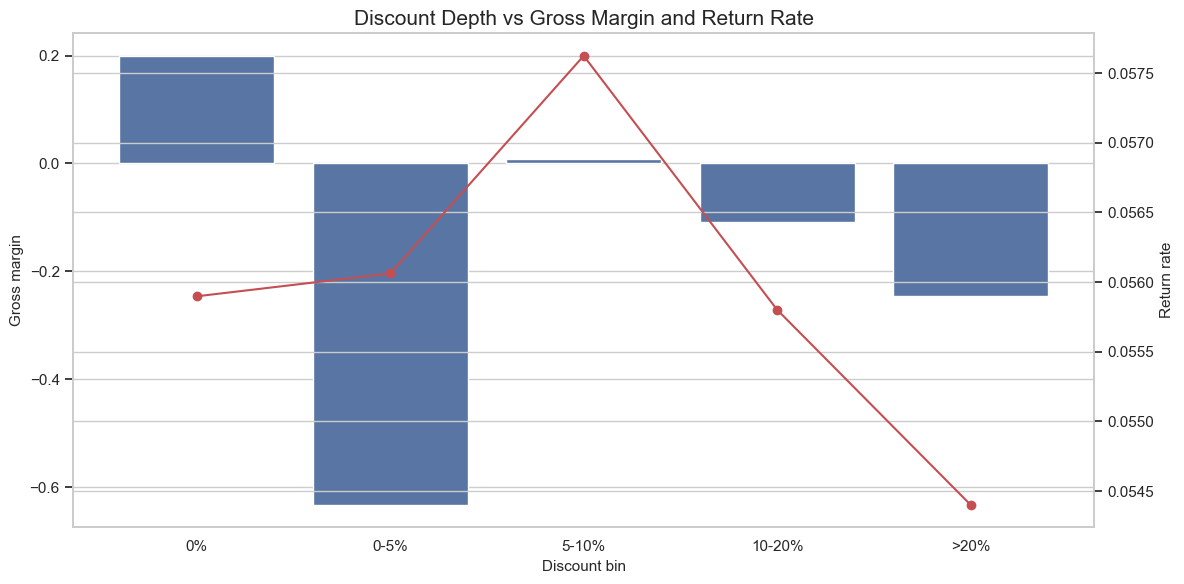

Saved figure: outputs\figures\fig10_discount_depth_margin_return.png


,discount_bin,lines,gross_margin,return_rate
0,0%,438353,0.199637,0.055898
1,0-5%,20852,-0.632791,0.056062
2,5-10%,26378,0.008735,0.057624
3,10-20%,203186,-0.108491,0.055801
4,>20%,25900,-0.245586,0.054402


In [19]:
# Chart 4B — Discount depth vs margin and return rate
x = line_items[line_items["gross_revenue"] > 0].copy()
x["discount_bin"] = pd.cut(
    x["discount_pct"],
    bins=[-0.001, 0, 0.05, 0.1, 0.2, 1],
    labels=["0%", "0-5%", "5-10%", "10-20%", ">20%"]
)

disc = x.groupby("discount_bin", as_index=False).agg(
    lines=("order_id", "count"),
    gross_margin=("gross_profit", lambda s: s.sum() / x.loc[s.index, "net_revenue"].sum() if x.loc[s.index, "net_revenue"].sum() else np.nan),
    return_rate=("is_returned", "mean"),
)

fig, ax1 = plt.subplots(figsize=(12, 6))
sns.barplot(data=disc, x="discount_bin", y="gross_margin", ax=ax1, color="#4C72B0")
ax1.set_title("Discount Depth vs Gross Margin and Return Rate")
ax1.set_xlabel("Discount bin")
ax1.set_ylabel("Gross margin")

ax2 = ax1.twinx()
ax2.plot(range(len(disc)), disc["return_rate"], color="#C44E52", marker="o")
ax2.set_ylabel("Return rate")

save_fig("fig10_discount_depth_margin_return.png")
disc

### Insight — Hiệu quả khuyến mãi và rủi ro bào mòn lợi nhuận

**Phát hiện chính:** Các dòng sản phẩm có khuyến mãi có thể đóng góp đáng kể vào doanh thu, nhưng không nên kết luận rằng khuyến mãi trực tiếp tạo ra tăng trưởng nếu chưa có phân tích nhân quả. Cách diễn giải phù hợp hơn là: các dòng có khuyến mãi có liên hệ với sự thay đổi về doanh thu, số lượng bán và biên lợi nhuận. Vì vậy, hiệu quả khuyến mãi cần được đánh giá đồng thời trên revenue, discount depth, gross margin và return rate.

**Ý nghĩa kinh doanh:** Nếu doanh nghiệp chỉ nhìn doanh thu sau khuyến mãi, rất dễ đánh giá sai hiệu quả thật. Một chương trình giảm giá có thể làm đơn hàng tăng nhưng đồng thời bào mòn gross margin, tăng áp lực tồn kho và không làm giảm tỷ lệ trả hàng. Trong trường hợp đó, doanh nghiệp đang “mua doanh thu” bằng lợi nhuận, thay vì tạo tăng trưởng bền vững.

**Đề xuất hành động:** Không nên discount dàn trải trên toàn bộ danh mục. Doanh nghiệp nên thiết lập ngưỡng kiểm soát biên lợi nhuận cho từng chương trình khuyến mãi. Khuyến mãi nên tập trung vào các category có nhu cầu tốt, biên lợi nhuận còn đủ an toàn và tỷ lệ trả hàng được kiểm soát. Với nhóm return cao hoặc margin thấp, nên hạn chế giảm giá trực tiếp và cân nhắc các hình thức khác như bundle, voucher theo ngưỡng đơn hàng, loyalty points hoặc clearance có kiểm soát.

# 5. Returns & Customer Experience

**Câu hỏi kinh doanh:** Sản phẩm nào tạo rủi ro hoàn trả? Vấn đề nằm ở size, mô tả, chất lượng hay giao hàng?

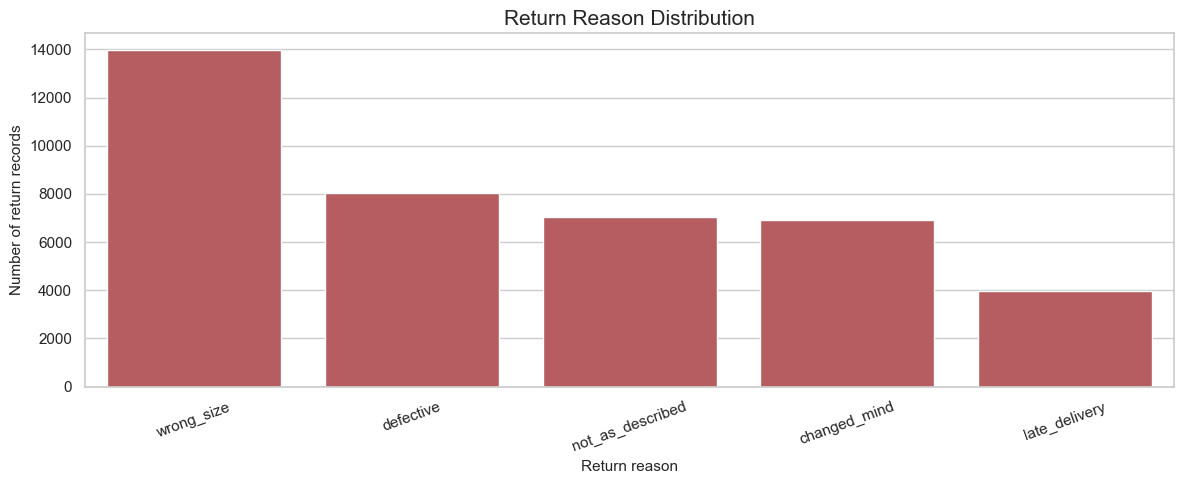

Saved figure: outputs\figures\fig11_return_reason_distribution.png


,return_reason,count,share
0,wrong_size,13967,0.349708
1,defective,8020,0.200806
2,not_as_described,7035,0.176144
3,changed_mind,6931,0.173540
4,late_delivery,3986,0.099802


In [20]:
# Chart 5A — Return reason distribution
reason = returns["return_reason"].value_counts().reset_index()
reason.columns = ["return_reason", "count"]
reason["share"] = reason["count"] / reason["count"].sum()

plt.figure(figsize=(12, 5))
sns.barplot(data=reason, x="return_reason", y="count", color="#C44E52")
plt.title("Return Reason Distribution")
plt.xlabel("Return reason")
plt.ylabel("Number of return records")
plt.xticks(rotation=20)
save_fig("fig11_return_reason_distribution.png")
reason

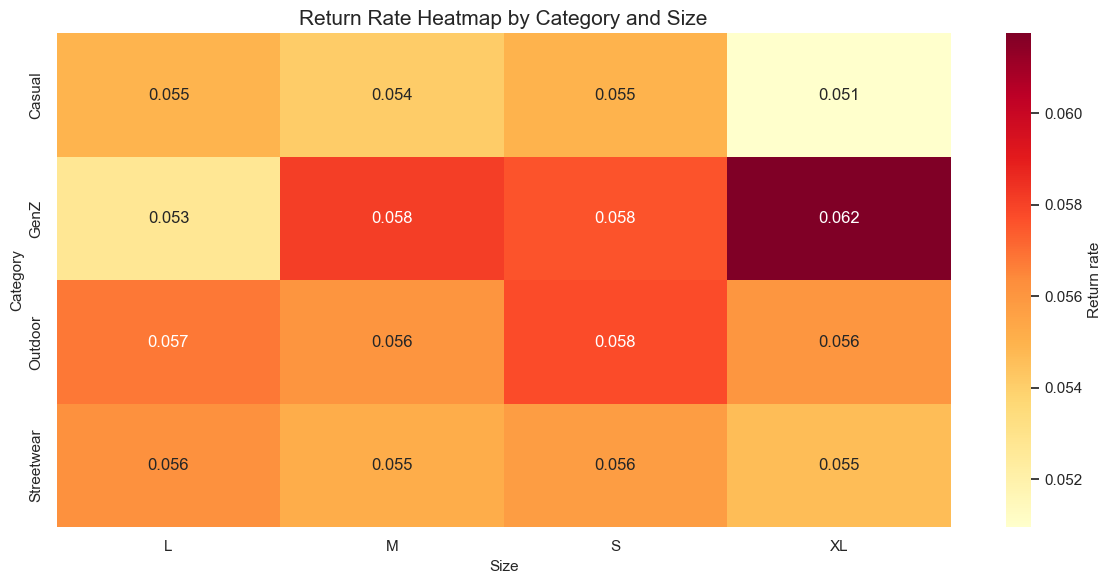

Saved figure: outputs\figures\fig12_return_rate_category_size_heatmap.png


,category,size,lines,return_rate
7,GenZ,XL,5393,0.061747
5,GenZ,M,10275,0.058102
10,Outdoor,S,55596,0.057756
6,GenZ,S,12899,0.057601
8,Outdoor,L,72086,0.056779
12,Streetwear,L,88765,0.056216
9,Outdoor,M,70915,0.056067
11,Outdoor,XL,61389,0.056036
14,Streetwear,S,95328,0.055776
13,Streetwear,M,87809,0.055177


In [21]:
# Chart 5B — Return rate heatmap by category and size
size_cat = line_items.groupby(["category", "size"], as_index=False).agg(
    lines=("order_id", "count"),
    return_rate=("is_returned", "mean")
)
heat_size = size_cat.pivot(index="category", columns="size", values="return_rate")

plt.figure(figsize=(12, 6))
sns.heatmap(heat_size, annot=True, fmt=".3f", cmap="YlOrRd", cbar_kws={"label": "Return rate"})
plt.title("Return Rate Heatmap by Category and Size")
plt.xlabel("Size")
plt.ylabel("Category")
save_fig("fig12_return_rate_category_size_heatmap.png")
size_cat.sort_values("return_rate", ascending=False).head(12)

### Insight — Trả hàng và trải nghiệm sau mua

**Phát hiện chính:** Các lý do trả hàng phản ánh trực tiếp điểm yếu trong trải nghiệm khách hàng sau mua. Nếu `wrong_size` là lý do nổi bật, vấn đề chính nằm ở khả năng khách hàng chọn đúng kích cỡ và kỳ vọng về form dáng sản phẩm. Nếu `defective` cao, rủi ro nằm ở chất lượng sản phẩm hoặc nhà cung cấp. Nếu `not_as_described` cao, vấn đề nằm ở khoảng cách giữa thông tin sản phẩm trên website và trải nghiệm thực tế khi nhận hàng.

**Ý nghĩa kinh doanh:** Trả hàng không chỉ làm giảm doanh thu thuần mà còn tạo thêm chi phí logistics ngược, hoàn tiền, xử lý kho và giảm mức độ hài lòng của khách hàng. Nếu không xử lý nguyên nhân gốc, doanh nghiệp có thể tiếp tục tăng doanh thu ban đầu nhưng lợi nhuận sau cùng bị suy giảm do chi phí hoàn trả và trải nghiệm khách hàng kém.

**Đề xuất hành động:** Với nhóm trả hàng do `wrong_size`, doanh nghiệp nên cải thiện size guide, ảnh người mẫu mặc thực tế, thông tin chiều cao/cân nặng mẫu và tư vấn chọn size. Với nhóm `defective`, cần tăng kiểm soát chất lượng nhà cung cấp và quy trình kiểm hàng trước khi giao. Với nhóm `not_as_described`, cần cải thiện ảnh sản phẩm, mô tả chất liệu, form dáng, màu sắc và hiển thị review thực tế để giảm khoảng cách kỳ vọng của khách hàng.

# 6. Inventory & Operations

**Câu hỏi kinh doanh:** Doanh nghiệp đang thiếu hàng ở đâu, dư hàng ở đâu, và có rủi ro mất doanh thu do stockout không?

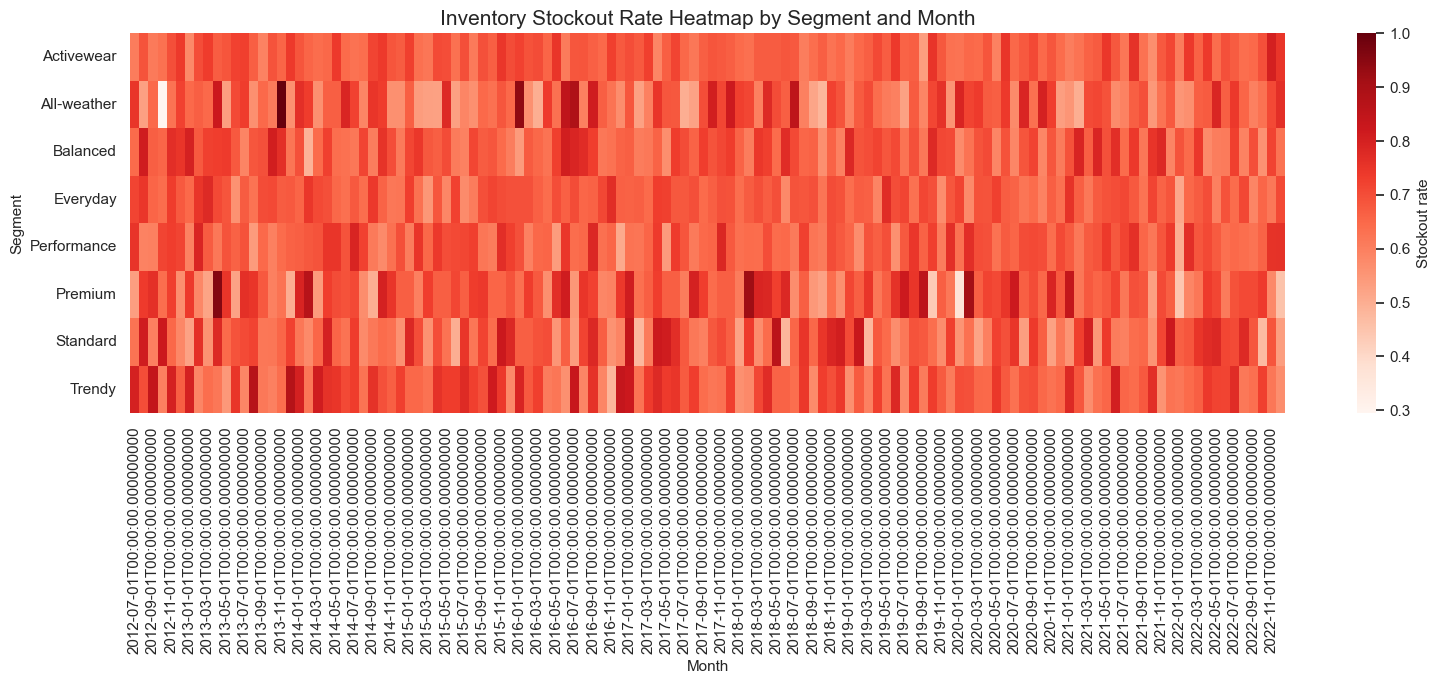

Saved figure: outputs\figures\fig13_inventory_stockout_heatmap.png


In [22]:
# Chart 6A — Stockout heatmap by segment and month
inventory["month"] = inventory["snapshot_date"].dt.to_period("M").dt.to_timestamp()
inv_seg = inventory.groupby(["month", "segment"], as_index=False).agg(
    stockout_rate=("stockout_flag", "mean"),
    overstock_rate=("overstock_flag", "mean"),
    avg_fill_rate=("fill_rate", "mean"),
    avg_sell_through=("sell_through_rate", "mean"),
    avg_days_of_supply=("days_of_supply", "mean"),
)

pivot_stockout = inv_seg.pivot(index="segment", columns="month", values="stockout_rate")

plt.figure(figsize=(16, 7))
sns.heatmap(pivot_stockout, cmap="Reds", cbar_kws={"label": "Stockout rate"})
plt.title("Inventory Stockout Rate Heatmap by Segment and Month")
plt.xlabel("Month")
plt.ylabel("Segment")
save_fig("fig13_inventory_stockout_heatmap.png")

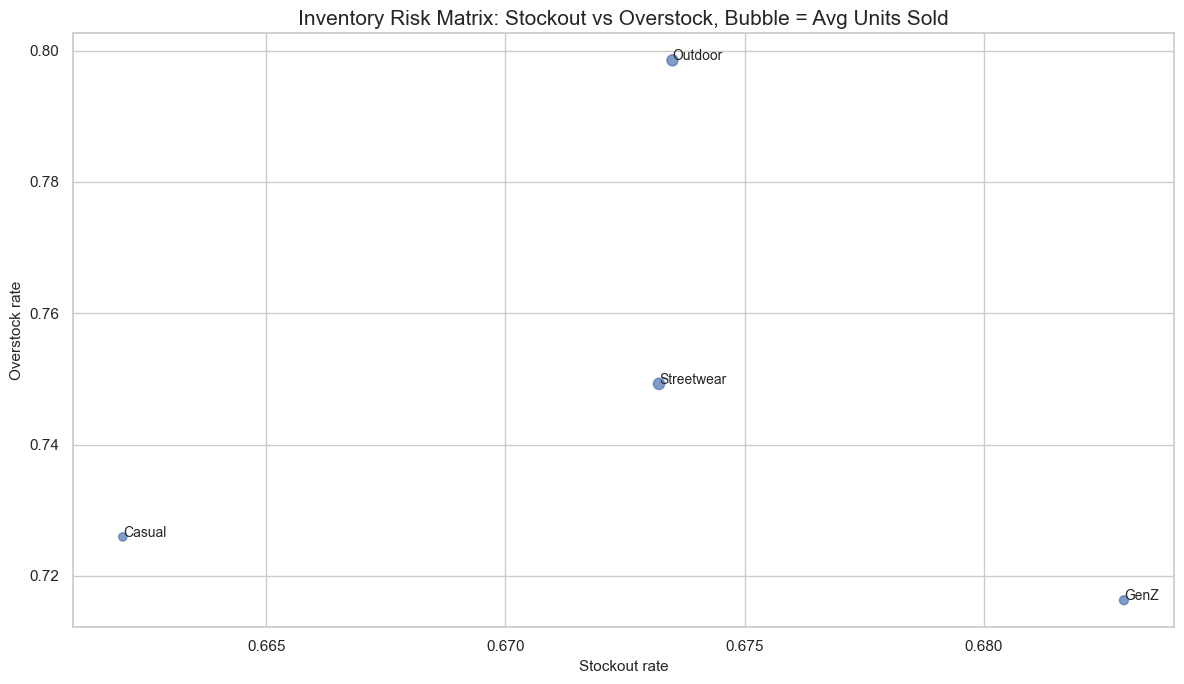

Saved figure: outputs\figures\fig14_inventory_risk_matrix.png


,category,stockout_rate,overstock_rate,avg_sell_through,avg_days_supply,avg_units_sold
1,GenZ,0.682927,0.716303,0.167978,718.812174,10.418271
2,Outdoor,0.673492,0.798527,0.135084,1068.837815,16.033729
3,Streetwear,0.673211,0.749259,0.159754,887.136692,16.488298
0,Casual,0.662004,0.725949,0.168390,459.132629,8.907222


In [23]:
# Chart 6B — Inventory risk matrix by category
inv_cat = inventory.groupby("category", as_index=False).agg(
    stockout_rate=("stockout_flag", "mean"),
    overstock_rate=("overstock_flag", "mean"),
    avg_sell_through=("sell_through_rate", "mean"),
    avg_days_supply=("days_of_supply", "mean"),
    avg_units_sold=("units_sold", "mean")
)

plt.figure(figsize=(12, 7))
plt.scatter(inv_cat["stockout_rate"], inv_cat["overstock_rate"], s=inv_cat["avg_units_sold"]*4, alpha=0.7)
for _, r in inv_cat.iterrows():
    plt.annotate(r["category"], (r["stockout_rate"], r["overstock_rate"]), fontsize=10)
plt.title("Inventory Risk Matrix: Stockout vs Overstock, Bubble = Avg Units Sold")
plt.xlabel("Stockout rate")
plt.ylabel("Overstock rate")
save_fig("fig14_inventory_risk_matrix.png")
inv_cat.sort_values("stockout_rate", ascending=False)

### Predictive Add-on — Cảnh báo sớm rủi ro tồn kho

Phần này bổ sung góc nhìn **Predictive/Prescriptive** cho tồn kho. Thay vì chỉ mô tả category nào từng stockout hoặc overstock, dashboard tạo thêm tín hiệu cảnh báo sớm để xác định nhóm category–segment có nguy cơ thiếu hàng trong kỳ kế hoạch tiếp theo.

Tín hiệu cảnh báo được xây dựng từ nhiều chỉ số vận hành gần đây, bao gồm stockout rate, reorder flag, sell-through rate và fill rate. Nhóm có stockout cao, reorder flag cao, sell-through cao và fill rate yếu cần được ưu tiên kiểm tra vì có khả năng mất doanh thu nếu không được bổ sung hàng kịp thời.

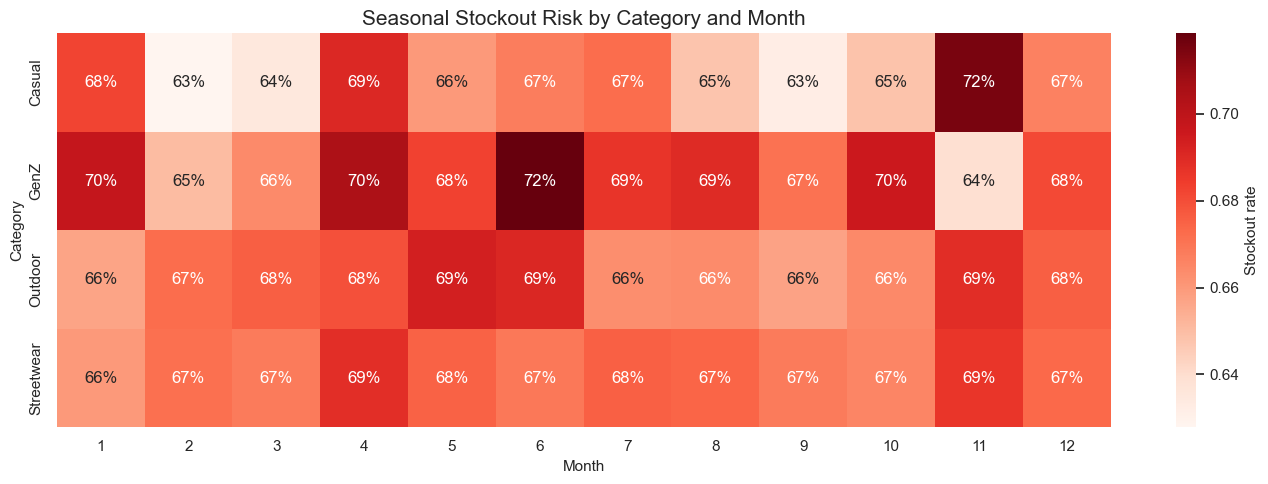

Saved figure: outputs\figures\fig14b_seasonal_stockout_risk.png


month_num,1,2,3,4,5,6,7,8,9,10,11,12
category,,,,,,,,,,,,
Casual,0.682353,0.627820,0.635088,0.690554,0.660000,0.667797,0.672297,0.647799,0.632107,0.648026,0.715302,0.666667
GenZ,0.697842,0.650327,0.664103,0.704600,0.682809,0.718535,0.686801,0.689579,0.670702,0.695545,0.639205,0.681081
Outdoor,0.657057,0.672279,0.675692,0.679407,0.693464,0.691159,0.662941,0.663793,0.657240,0.664603,0.688801,0.675716
Streetwear,0.659963,0.671527,0.668235,0.688700,0.675140,0.668934,0.675492,0.674554,0.668504,0.665406,0.686356,0.673494


In [24]:
# Chart 6C — Seasonal stockout risk by category and month
inventory_season = inventory.copy()
inventory_season["month_num"] = inventory_season["snapshot_date"].dt.month

stockout_month_cat = (
    inventory_season
    .groupby(["category", "month_num"], as_index=False)
    .agg(stockout_rate=("stockout_flag", "mean"))
)
stockout_heat = stockout_month_cat.pivot(
    index="category",
    columns="month_num",
    values="stockout_rate"
)

plt.figure(figsize=(14, 5))
sns.heatmap(stockout_heat, cmap="Reds", annot=True, fmt=".0%", cbar_kws={"label": "Stockout rate"})
plt.title("Seasonal Stockout Risk by Category and Month")
plt.xlabel("Month")
plt.ylabel("Category")
save_fig("fig14b_seasonal_stockout_risk.png")
stockout_heat


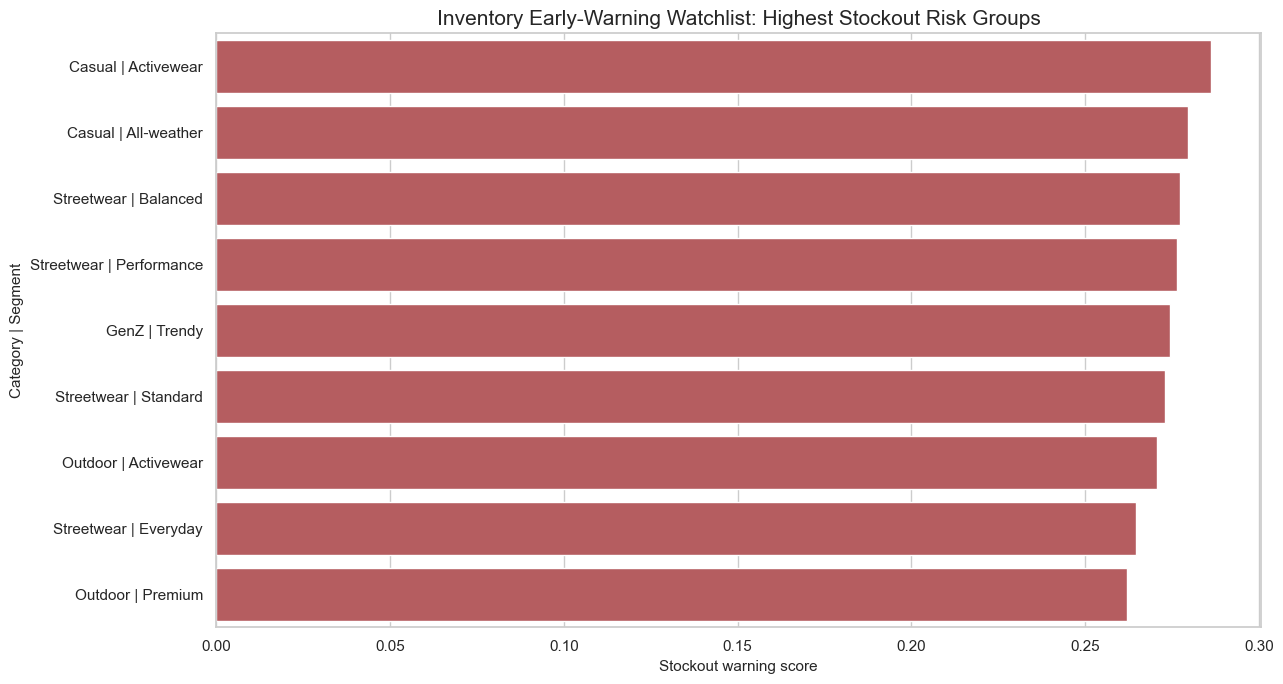

Saved figure: outputs\figures\fig14c_inventory_early_warning_watchlist.png


,category,segment,stockout_warning_score,stockout_rate,reorder_rate,avg_sell_through,avg_fill_rate,avg_days_supply
0,Casual,Activewear,0.286192,0.653846,0.0,0.212465,0.971804,210.384615
1,Casual,All-weather,0.279486,0.680672,0.0,0.143744,0.964567,689.573109
5,Streetwear,Balanced,0.277136,0.647059,0.0,0.179414,0.961255,1349.775294
7,Streetwear,Performance,0.276397,0.669444,0.0,0.145033,0.961112,1447.742778
2,GenZ,Trendy,0.274384,0.668524,0.0,0.141046,0.965738,1260.188579
8,Streetwear,Standard,0.272864,0.658537,0.0,0.149343,0.966398,378.562602
3,Outdoor,Activewear,0.270699,0.700920,0.0,0.078103,0.960992,2626.418712
6,Streetwear,Everyday,0.264712,0.660714,0.0,0.112849,0.964999,2150.717679
4,Outdoor,Premium,0.262092,0.631818,0.0,0.144733,0.968182,1039.448636


In [25]:
# Chart 6D — Inventory early-warning watchlist using recent months
latest_snapshot = inventory["snapshot_date"].max()
recent_start = latest_snapshot - pd.DateOffset(months=6)
recent_inventory = inventory[inventory["snapshot_date"] >= recent_start].copy()

watchlist = (
    recent_inventory
    .groupby(["category", "segment"], as_index=False)
    .agg(
        stockout_rate=("stockout_flag", "mean"),
        reorder_rate=("reorder_flag", "mean"),
        avg_sell_through=("sell_through_rate", "mean"),
        avg_fill_rate=("fill_rate", "mean"),
        avg_days_supply=("days_of_supply", "mean"),
        avg_units_sold=("units_sold", "mean"),
    )
)

# Risk score: high stockout + high reorder + high sell-through + weak fill rate
watchlist["stockout_warning_score"] = (
    0.35 * watchlist["stockout_rate"]
    + 0.25 * watchlist["reorder_rate"]
    + 0.25 * watchlist["avg_sell_through"]
    + 0.15 * (1 - watchlist["avg_fill_rate"])
)
watchlist["label"] = watchlist["category"] + " | " + watchlist["segment"]
watchlist_top = watchlist.sort_values("stockout_warning_score", ascending=False).head(12)

plt.figure(figsize=(13, 7))
sns.barplot(
    data=watchlist_top,
    x="stockout_warning_score",
    y="label",
    color="#C44E52"
)
plt.title("Inventory Early-Warning Watchlist: Highest Stockout Risk Groups")
plt.xlabel("Stockout warning score")
plt.ylabel("Category | Segment")
save_fig("fig14c_inventory_early_warning_watchlist.png")
watchlist_top[[
    "category", "segment", "stockout_warning_score", "stockout_rate",
    "reorder_rate", "avg_sell_through", "avg_fill_rate", "avg_days_supply"
]]


### Diagnostic Add-on — Dead stock và nghịch lý tồn kho

Phần này phân tích các tín hiệu bất thường trong vận hành tồn kho, bao gồm dead stock, `days_of_supply` rất cao và trường hợp một số bản ghi vừa có `stockout_flag` vừa có `overstock_flag`. Thay vì xem đây đơn thuần là lỗi dữ liệu, dashboard sử dụng các tín hiệu này để đánh giá khả năng phân bổ tồn kho chưa tối ưu.

Mục tiêu của phần này là kiểm tra liệu doanh nghiệp có đang rơi vào tình trạng: tổng tồn kho nhìn có vẻ lớn, nhưng hàng đúng nhu cầu vẫn thiếu. Đây là một vấn đề vận hành quan trọng trong thương mại điện tử thời trang, nơi rủi ro thường nằm ở cấp SKU, size, category hoặc segment chứ không chỉ ở tổng lượng hàng.

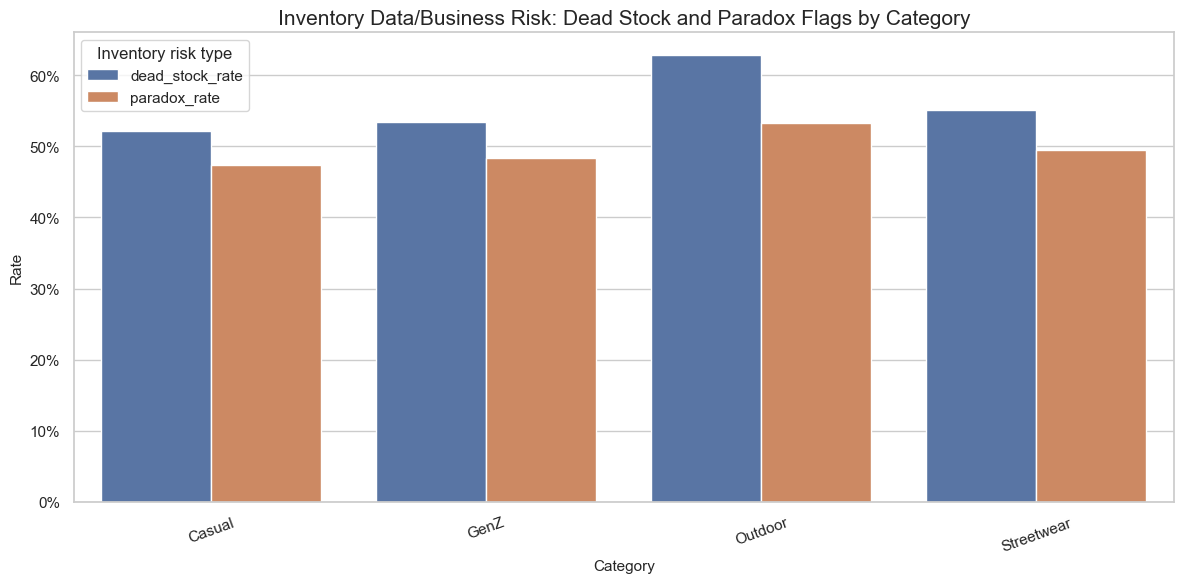

Saved figure: outputs\figures\fig14d_dead_stock_paradox_by_category.png


,category,dead_stock_rate,paradox_rate,avg_days_supply,avg_units_sold
2,Outdoor,0.628836,0.532209,1068.837815,16.033729
3,Streetwear,0.550580,0.495487,887.136692,16.488298
1,GenZ,0.533590,0.483954,718.812174,10.418271
0,Casual,0.521838,0.473880,459.132629,8.907222


In [26]:
# Chart 6E — Dead stock and inventory paradox by category
inv_quality = inventory.copy()
inv_quality["dead_stock_flag"] = inv_quality["days_of_supply"] > 180
inv_quality["paradox_flag"] = (
    inv_quality["stockout_flag"].fillna(0).astype(int).eq(1)
    & inv_quality["overstock_flag"].fillna(0).astype(int).eq(1)
)

inv_quality_cat = (
    inv_quality.groupby("category", as_index=False)
    .agg(
        dead_stock_rate=("dead_stock_flag", "mean"),
        paradox_rate=("paradox_flag", "mean"),
        avg_days_supply=("days_of_supply", "mean"),
        avg_units_sold=("units_sold", "mean"),
    )
)

plot_quality = inv_quality_cat.melt(
    id_vars="category",
    value_vars=["dead_stock_rate", "paradox_rate"],
    var_name="Inventory risk type",
    value_name="Rate"
)

plt.figure(figsize=(12, 6))
sns.barplot(data=plot_quality, x="category", y="Rate", hue="Inventory risk type")
plt.title("Inventory Data/Business Risk: Dead Stock and Paradox Flags by Category")
plt.xlabel("Category")
plt.ylabel("Rate")
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f"{x:.0%}"))
plt.xticks(rotation=20)
save_fig("fig14d_dead_stock_paradox_by_category.png")

inv_quality_cat.sort_values("dead_stock_rate", ascending=False)


### Insight — Tồn kho dư không đồng nghĩa với đủ hàng

**Phát hiện chính:** Dead stock, overstock và stockout có thể cùng tồn tại trong cùng hệ thống tồn kho. Điều này cho thấy vấn đề không chỉ là doanh nghiệp đang thiếu hàng hay dư hàng tổng thể, mà là tồn kho có thể đang bị phân bổ sai giữa các SKU, size, category hoặc segment. Một nhóm sản phẩm có thể đang dư hàng ở các SKU bán chậm nhưng lại thiếu hàng ở các SKU có nhu cầu thật.

**Ý nghĩa kinh doanh:** Nếu chỉ nhìn tổng tồn kho, doanh nghiệp có thể tưởng rằng hàng đang dư và giảm nhập hàng, trong khi các SKU bán chạy vẫn bị stockout. Ngược lại, nếu chỉ nhìn stockout, doanh nghiệp có thể tiếp tục nhập thêm hàng mà không xử lý dead stock. Cả hai cách nhìn đều có thể dẫn đến mất doanh thu, tăng chi phí lưu kho, áp lực giảm giá và sử dụng vốn kém hiệu quả.

**Đề xuất hành động:** Doanh nghiệp nên quản trị tồn kho ở cấp chi tiết hơn, tối thiểu là category–segment và lý tưởng là cấp SKU/size. Nhóm có stockout cao và sell-through cao cần được reorder sớm hơn, tăng tồn kho an toàn và kiểm tra lead time nhập hàng. Nhóm có overstock cao, days of supply cao hoặc sell-through thấp cần được tách riêng để chạy clearance campaign, bundle hoặc giảm kế hoạch nhập hàng kỳ sau. Đây là một insight Prescriptive quan trọng vì trực tiếp chuyển hóa dữ liệu thành quyết định mua hàng, phân bổ tồn kho và xử lý hàng chậm luân chuyển.

# 7. Web Traffic & Marketing Efficiency

**Câu hỏi kinh doanh:** Traffic có chuyển thành đơn hàng không? Nguồn nào chất lượng hơn?

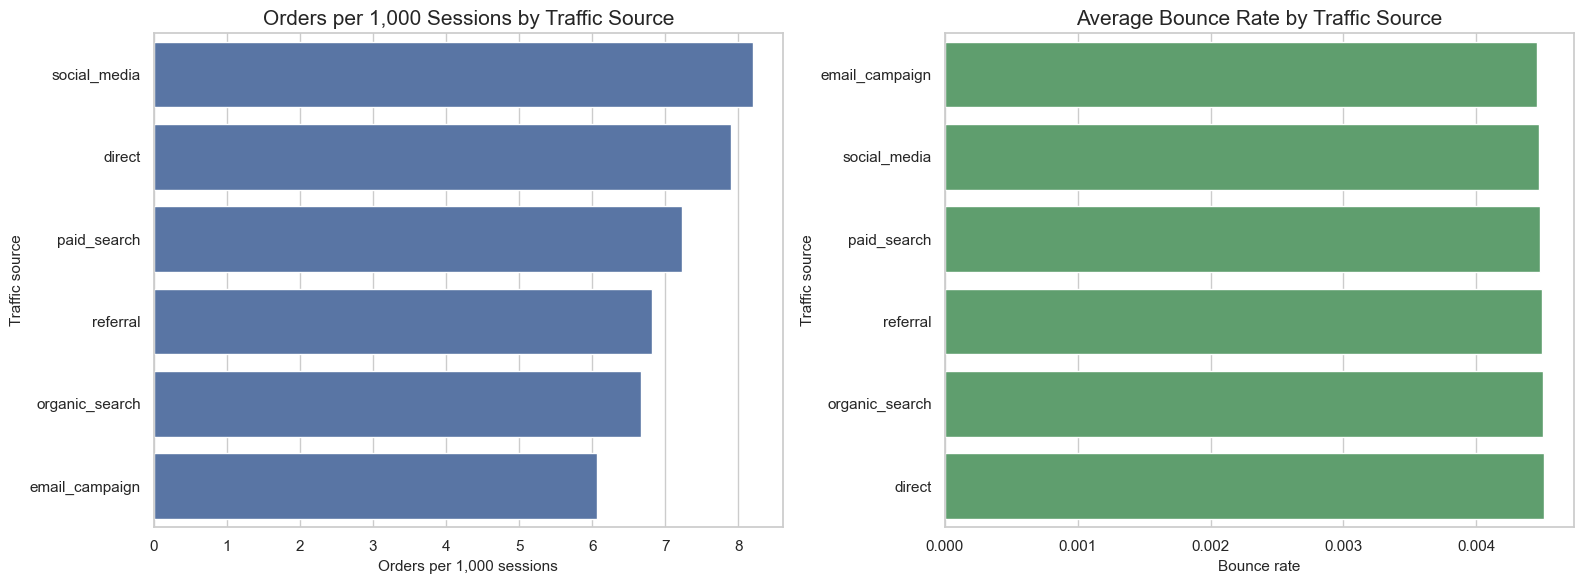

Saved figure: outputs\figures\fig15_traffic_source_efficiency.png


,traffic_source,sessions,avg_bounce_rate,avg_session_duration,order_source,orders,orders_per_1k_sessions
5,social_media,15816226,0.004476,210.290190,social_media,129710,8.201071
0,direct,6571549,0.004511,207.678195,direct,51951,7.905442
3,paid_search,19598271,0.004478,209.362117,paid_search,141652,7.227780
4,referral,9476845,0.004499,207.558667,referral,64565,6.812921
2,organic_search,27196976,0.004504,211.153945,organic_search,181495,6.673352
1,email_campaign,12792670,0.004458,213.220594,email_campaign,77572,6.063785


In [27]:
# Chart 7A — Orders per 1,000 sessions by traffic source
traffic_src = web_traffic.groupby("traffic_source", as_index=False).agg(
    sessions=("sessions", "sum"),
    avg_bounce_rate=("bounce_rate", "mean"),
    avg_session_duration=("avg_session_duration_sec", "mean"),
)
orders_src = orders.groupby("order_source", as_index=False).agg(orders=("order_id", "nunique"))

efficiency = traffic_src.merge(orders_src, left_on="traffic_source", right_on="order_source", how="left")
efficiency["orders"] = efficiency["orders"].fillna(0)
efficiency["orders_per_1k_sessions"] = efficiency["orders"] / efficiency["sessions"] * 1000

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(data=efficiency.sort_values("orders_per_1k_sessions", ascending=False),
            x="orders_per_1k_sessions", y="traffic_source", ax=axes[0], color="#4C72B0")
axes[0].set_title("Orders per 1,000 Sessions by Traffic Source")
axes[0].set_xlabel("Orders per 1,000 sessions")
axes[0].set_ylabel("Traffic source")

sns.barplot(data=efficiency.sort_values("avg_bounce_rate"),
            x="avg_bounce_rate", y="traffic_source", ax=axes[1], color="#55A868")
axes[1].set_title("Average Bounce Rate by Traffic Source")
axes[1].set_xlabel("Bounce rate")
axes[1].set_ylabel("Traffic source")

save_fig("fig15_traffic_source_efficiency.png")
efficiency.sort_values("orders_per_1k_sessions", ascending=False)

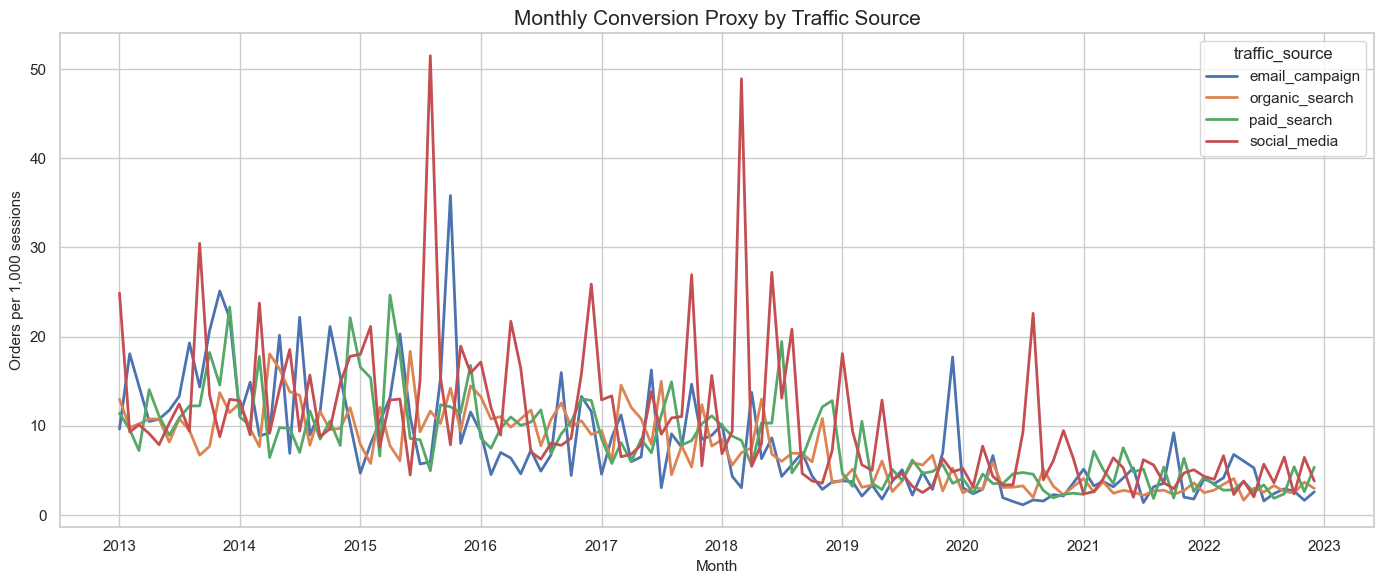

Saved figure: outputs\figures\fig16_monthly_conversion_proxy.png


,traffic_source,orders_per_1k_sessions
3,social_media,10.402056
2,paid_search,8.210186
0,email_campaign,7.908373
1,organic_search,7.393663


In [28]:
# Chart 7B — Monthly conversion proxy by traffic source
traffic_m = web_traffic.copy()
traffic_m["month"] = traffic_m["date"].dt.to_period("M").dt.to_timestamp()
traffic_m = traffic_m.groupby(["month", "traffic_source"], as_index=False).agg(sessions=("sessions", "sum"))

orders_m = orders.copy()
orders_m["month"] = orders_m["order_date"].dt.to_period("M").dt.to_timestamp()
orders_m = orders_m.groupby(["month", "order_source"], as_index=False).agg(orders=("order_id", "nunique")).rename(columns={"order_source": "traffic_source"})

conv = traffic_m.merge(orders_m, on=["month", "traffic_source"], how="left")
conv["orders"] = conv["orders"].fillna(0)
conv["orders_per_1k_sessions"] = conv["orders"] / conv["sessions"] * 1000

top_src = conv.groupby("traffic_source")["orders"].sum().sort_values(ascending=False).head(4).index
conv_top = conv[conv["traffic_source"].isin(top_src)]

plt.figure(figsize=(14, 6))
sns.lineplot(data=conv_top, x="month", y="orders_per_1k_sessions", hue="traffic_source", linewidth=2)
plt.title("Monthly Conversion Proxy by Traffic Source")
plt.xlabel("Month")
plt.ylabel("Orders per 1,000 sessions")
save_fig("fig16_monthly_conversion_proxy.png")
conv_top.groupby("traffic_source", as_index=False)["orders_per_1k_sessions"].mean().sort_values("orders_per_1k_sessions", ascending=False)

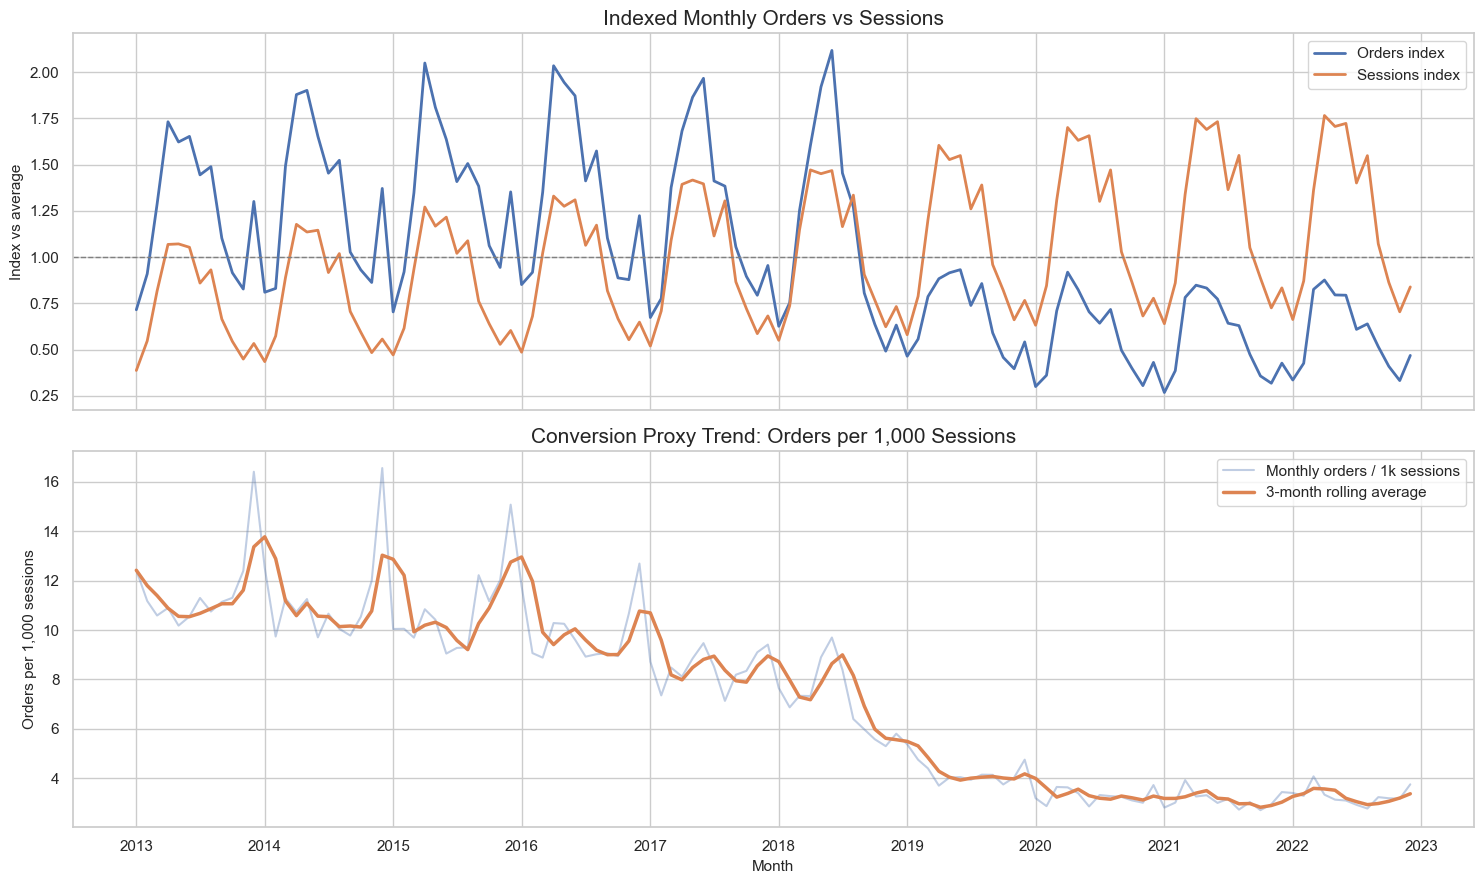

Saved figure: outputs\figures\fig17_traffic_orders_conversion_warning.png


,month,orders,sessions,orders_per_1k_sessions,orders_index,sessions_index,conversion_3m_avg
108,2022-01-01,1719,505009,3.403900,0.335472,0.662651,3.264358
109,2022-02-01,2182,663620,3.288026,0.425829,0.870773,3.377645
110,2022-03-01,4231,1037755,4.077070,0.825703,1.361697,3.589665
111,2022-04-01,4489,1345666,3.335895,0.876053,1.765724,3.566997
112,2022-05-01,4076,1300613,3.133907,0.795454,1.706607,3.515624
113,2022-06-01,4068,1313081,3.098057,0.793893,1.722967,3.189286
114,2022-07-01,3122,1067671,2.924122,0.609276,1.400951,3.052029
115,2022-08-01,3274,1180206,2.774092,0.638939,1.548614,2.932090
116,2022-09-01,2643,816742,3.236028,0.515796,1.071693,2.978081
117,2022-10-01,2097,657381,3.189931,0.409241,0.862586,3.066684


In [29]:
# Chart 7C — Traffic-orders conversion warning signal
orders_month = (
    orders.assign(month=orders["order_date"].dt.to_period("M").dt.to_timestamp())
    .groupby("month", as_index=False)
    .agg(orders=("order_id", "nunique"))
)

traffic_month = (
    web_traffic.assign(month=web_traffic["date"].dt.to_period("M").dt.to_timestamp())
    .groupby("month", as_index=False)
    .agg(sessions=("sessions", "sum"))
)

traffic_orders = (
    orders_month
    .merge(traffic_month, on="month", how="inner")
    .sort_values("month")
)

traffic_orders["orders_per_1k_sessions"] = traffic_orders["orders"] / traffic_orders["sessions"] * 1000
traffic_orders["orders_index"] = traffic_orders["orders"] / traffic_orders["orders"].mean()
traffic_orders["sessions_index"] = traffic_orders["sessions"] / traffic_orders["sessions"].mean()
traffic_orders["conversion_3m_avg"] = traffic_orders["orders_per_1k_sessions"].rolling(3, min_periods=1).mean()

fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=True)

axes[0].plot(traffic_orders["month"], traffic_orders["orders_index"], label="Orders index", linewidth=2)
axes[0].plot(traffic_orders["month"], traffic_orders["sessions_index"], label="Sessions index", linewidth=2)
axes[0].axhline(1.0, color="gray", linestyle="--", linewidth=1)
axes[0].set_title("Indexed Monthly Orders vs Sessions")
axes[0].set_ylabel("Index vs average")
axes[0].legend()

axes[1].plot(traffic_orders["month"], traffic_orders["orders_per_1k_sessions"], alpha=0.35, label="Monthly orders / 1k sessions")
axes[1].plot(traffic_orders["month"], traffic_orders["conversion_3m_avg"], linewidth=2.5, label="3-month rolling average")
axes[1].set_title("Conversion Proxy Trend: Orders per 1,000 Sessions")
axes[1].set_ylabel("Orders per 1,000 sessions")
axes[1].set_xlabel("Month")
axes[1].legend()

save_fig("fig17_traffic_orders_conversion_warning.png")
traffic_orders.tail(12)


### Insight — Hiệu quả traffic và chất lượng chuyển đổi

**Phát hiện chính:** Traffic cao chưa chắc phản ánh hiệu quả kinh doanh tốt. Một nguồn truy cập có thể tạo nhiều sessions nhưng không tạo ra lượng orders tương ứng. Vì vậy, cần đánh giá marketing channel bằng conversion proxy, orders per session, bounce rate và xu hướng tăng trưởng đơn hàng, thay vì chỉ nhìn tổng traffic.

**Ý nghĩa kinh doanh:** Khi sessions tăng nhưng orders không tăng tương ứng, nút thắt có thể nằm ở chất lượng traffic hoặc trải nghiệm chuyển đổi. Các nguyên nhân có thể bao gồm landing page chưa phù hợp, sản phẩm không khớp nhu cầu người dùng, ưu đãi chưa đủ hấp dẫn, trải nghiệm checkout có ma sát hoặc thông điệp marketing không nhất quán với sản phẩm thực tế.

**Đề xuất hành động:** Doanh nghiệp nên phân bổ ngân sách marketing dựa trên chất lượng chuyển đổi, không chỉ dựa trên số phiên truy cập. Các kênh có conversion proxy tốt và bounce rate thấp nên được ưu tiên mở rộng. Với các kênh có traffic cao nhưng conversion thấp, cần tối ưu landing page, thông điệp quảng cáo, đề xuất sản phẩm, ưu đãi và quy trình checkout trước khi tiếp tục tăng ngân sách.

# 8. Prescriptive Action Playbook

Phần này dùng các kết quả ở trên để biến insight thành hành động. Đây là phần giúp dashboard đạt cấp độ **Prescriptive** trong rubric.

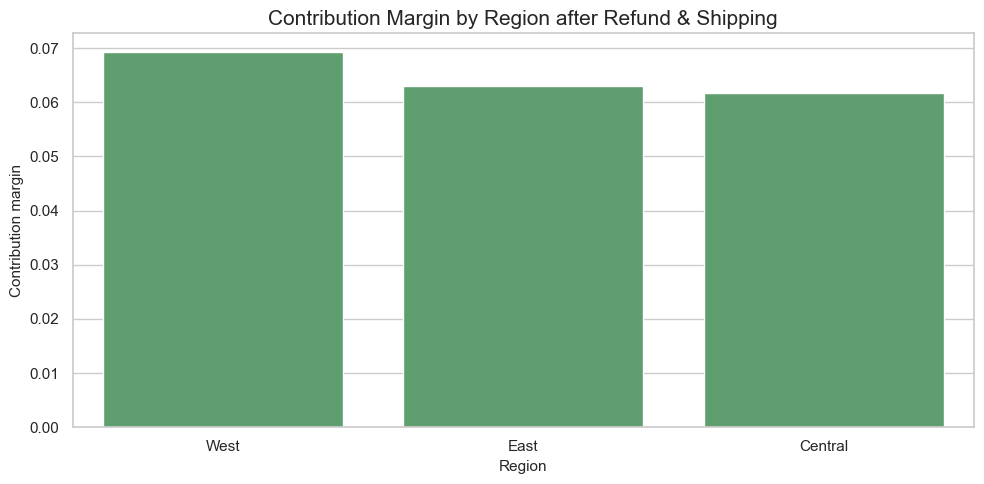

Saved figure: outputs\figures\fig18_region_contribution_margin.png


,region,orders,net_revenue,gross_profit,refund,shipping_fee,contribution_profit,contribution_margin
2,West,167642,3.670227e+09,3.787095e+08,1.237297e+08,791855.41,2.541880e+08,0.069257
1,East,294612,7.291151e+09,6.956483e+08,2.354817e+08,1244288.28,4.589223e+08,0.062942
0,Central,184691,4.719491e+09,4.430609e+08,1.513871e+08,773165.97,2.909007e+08,0.061638


In [30]:
# Chart 8A — Contribution margin by region after refund and shipping
order_fin = line_items.groupby("order_id", as_index=False).agg(
    net_revenue=("net_revenue", "sum"),
    line_cogs=("line_cogs", "sum"),
    gross_profit=("gross_profit", "sum"),
)
refund_order = returns.groupby("order_id", as_index=False).agg(refund_amount=("refund_amount", "sum"))
ship_fee_order = shipments.groupby("order_id", as_index=False).agg(shipping_fee=("shipping_fee", "sum"))
order_region = orders.merge(geography[["zip", "region"]].drop_duplicates("zip"), on="zip", how="left")[["order_id", "region"]]

unit = order_fin.merge(refund_order, on="order_id", how="left").merge(ship_fee_order, on="order_id", how="left").merge(order_region, on="order_id", how="left")
unit[["refund_amount", "shipping_fee"]] = unit[["refund_amount", "shipping_fee"]].fillna(0)
unit["contribution_profit"] = unit["gross_profit"] - unit["refund_amount"] - unit["shipping_fee"]
unit["contribution_margin"] = unit["contribution_profit"] / unit["net_revenue"].replace(0, np.nan)

region_unit = unit.groupby("region", as_index=False).agg(
    orders=("order_id", "nunique"),
    net_revenue=("net_revenue", "sum"),
    gross_profit=("gross_profit", "sum"),
    refund=("refund_amount", "sum"),
    shipping_fee=("shipping_fee", "sum"),
    contribution_profit=("contribution_profit", "sum"),
)
region_unit["contribution_margin"] = region_unit["contribution_profit"] / region_unit["net_revenue"]

plt.figure(figsize=(10, 5))
sns.barplot(data=region_unit.sort_values("contribution_margin", ascending=False), x="region", y="contribution_margin", color="#55A868")
plt.title("Contribution Margin by Region after Refund & Shipping")
plt.xlabel("Region")
plt.ylabel("Contribution margin")
save_fig("fig18_region_contribution_margin.png")
region_unit.sort_values("contribution_margin", ascending=False)

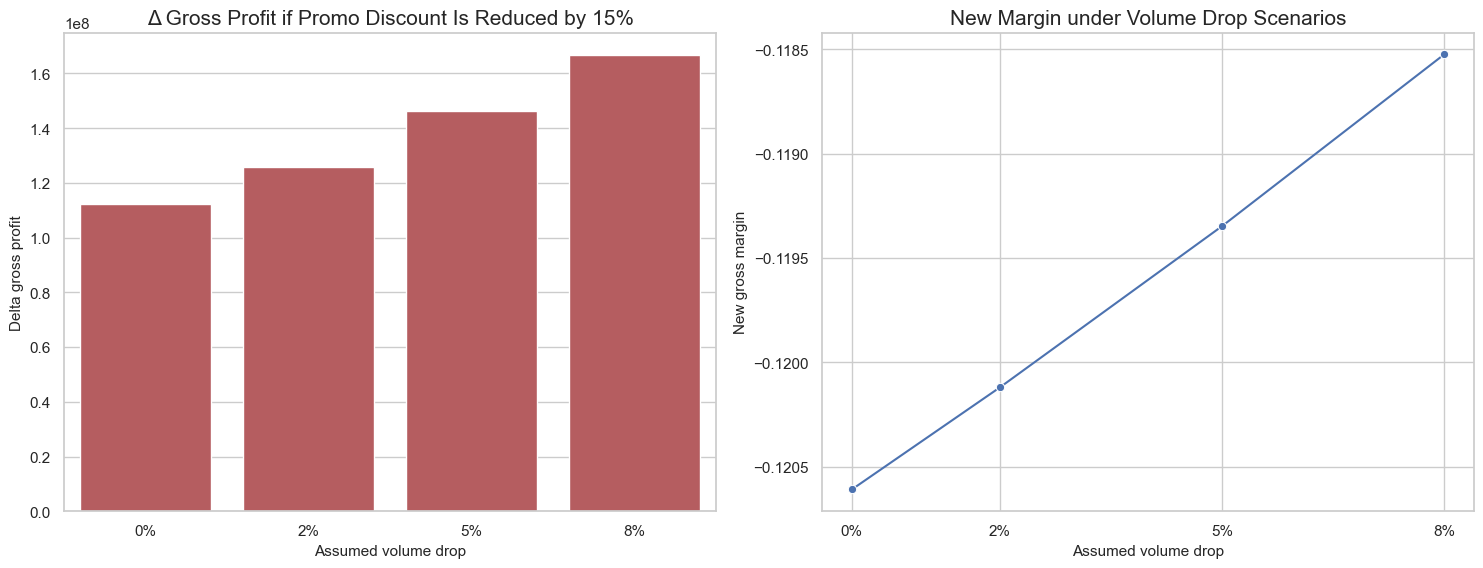

Saved figure: outputs\figures\fig19_promo_discount_simulator.png


,volume_drop_pct,new_revenue,new_gross_profit,delta_gross_profit,new_margin
0,0.00,4.685830e+09,-5.651555e+08,1.124411e+08,-0.120609
1,0.02,4.592114e+09,-5.516036e+08,1.259930e+08,-0.120120
2,0.05,4.451539e+09,-5.312757e+08,1.463209e+08,-0.119347
3,0.08,4.310964e+09,-5.109478e+08,1.666488e+08,-0.118523


In [31]:
# Chart 8B — Prescriptive simulator: reduce promo discount by 15%
promo_lines = line_items[line_items["promo_applied"]].copy()
base_rev = promo_lines["net_revenue"].sum()
base_gp = promo_lines["gross_profit"].sum()
base_disc = promo_lines["discount_amount"].fillna(0).sum()

scenarios = []
for volume_drop in [0.00, 0.02, 0.05, 0.08]:
    new_discount = base_disc * 0.85
    recovered_discount = base_disc - new_discount
    new_revenue = base_rev * (1 - volume_drop)
    gp_lost_from_volume = base_gp * volume_drop
    new_gp = base_gp + recovered_discount - gp_lost_from_volume
    scenarios.append({
        "volume_drop_pct": volume_drop,
        "new_revenue": new_revenue,
        "new_gross_profit": new_gp,
        "delta_gross_profit": new_gp - base_gp,
        "new_margin": new_gp / new_revenue if new_revenue else np.nan,
    })

sim = pd.DataFrame(scenarios)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.barplot(data=sim, x="volume_drop_pct", y="delta_gross_profit", ax=axes[0], color="#C44E52")
axes[0].set_title("Δ Gross Profit if Promo Discount Is Reduced by 15%")
axes[0].set_xlabel("Assumed volume drop")
axes[0].set_ylabel("Delta gross profit")
axes[0].set_xticklabels([f"{v:.0%}" for v in sim["volume_drop_pct"]])

sns.lineplot(data=sim, x="volume_drop_pct", y="new_margin", marker="o", ax=axes[1], color="#4C72B0")
axes[1].set_title("New Margin under Volume Drop Scenarios")
axes[1].set_xlabel("Assumed volume drop")
axes[1].set_ylabel("New gross margin")
axes[1].set_xticks(sim["volume_drop_pct"])
axes[1].set_xticklabels([f"{v:.0%}" for v in sim["volume_drop_pct"]])

save_fig("fig19_promo_discount_simulator.png")
sim

In [32]:
# Final action playbook table
best_source = efficiency.sort_values("orders_per_1k_sessions", ascending=False).iloc[0]["traffic_source"]
top_return_reason = returns["return_reason"].value_counts().index[0]
worst_stockout_category = inv_cat.sort_values("stockout_rate", ascending=False).iloc[0]["category"]
worst_overstock_category = inv_cat.sort_values("overstock_rate", ascending=False).iloc[0]["category"]

playbook = pd.DataFrame([
    {
        "Priority": 1,
        "Focus": "Retention and customer quality",
        "Action": "Run CRM/win-back campaigns for cohorts/channels with low repeat rate.",
        "KPI": "Repeat rate, revenue from returning customers, orders/customer",
    },
    {
        "Priority": 2,
        "Focus": "Promotion efficiency",
        "Action": "Reduce blanket discounts; prioritize discount only where margin remains healthy.",
        "KPI": "Gross margin, discount rate, promo revenue, return rate",
    },
    {
        "Priority": 3,
        "Focus": "Return reduction",
        "Action": f"Address dominant return reason: {top_return_reason}; improve size guide/product description/QC depending on reason.",
        "KPI": "Return rate, refund amount, rating",
    },
    {
        "Priority": 4,
        "Focus": "Inventory allocation",
        "Action": f"Increase reorder discipline for high-stockout category: {worst_stockout_category}; clear overstock in {worst_overstock_category}.",
        "KPI": "Stockout rate, overstock rate, sell-through, days of supply",
    },
    {
        "Priority": 5,
        "Focus": "Marketing channel quality",
        "Action": f"Scale high-efficiency source ({best_source}); fix landing/checkout for sources with weak conversion proxy.",
        "KPI": "Orders/1k sessions, bounce rate, conversion proxy",
    },
])
playbook

,Priority,Focus,Action,KPI
0,1,Retention and customer quality,Run CRM/win-back campaigns for cohorts/channel...,"Repeat rate, revenue from returning customers,..."
1,2,Promotion efficiency,Reduce blanket discounts; prioritize discount ...,"Gross margin, discount rate, promo revenue, re..."
2,3,Return reduction,Address dominant return reason: wrong_size; im...,"Return rate, refund amount, rating"
3,4,Inventory allocation,Increase reorder discipline for high-stockout ...,"Stockout rate, overstock rate, sell-through, d..."
4,5,Marketing channel quality,Scale high-efficiency source (social_media); f...,"Orders/1k sessions, bounce rate, conversion proxy"


# Final Dashboard-to-Report Selection

Để đưa vào báo cáo PDF tối đa 4 trang, **không nên dùng toàn bộ chart**. Nên chọn 6–8 chart mạnh nhất, ưu tiên các chart vừa có insight sâu vừa phục vụ đầy đủ bốn cấp độ **Descriptive → Diagnostic → Predictive → Prescriptive**:

1. `fig1_revenue_profit_trend.png` — Tổng quan doanh thu và lợi nhuận gộp.
2. `fig2_revenue_seasonality_month_heatmap.png` hoặc `fig3b_monthly_seasonal_demand_index.png` — Mùa vụ và tín hiệu dự báo nhu cầu.
3. `fig3c_pre_post_2019_business_health_index.png` — Chẩn đoán sức khỏe kinh doanh trước/sau 2019.
4. `fig5_new_vs_returning_revenue_mix.png` hoặc `fig5b_pre_post_repeat_purchase_diagnostic.png` — Retention và repeat purchase.
5. `fig7_segment_portfolio_map.png` hoặc `fig8_category_revenue_share_over_time.png` — Product portfolio và rủi ro phụ thuộc category.
6. `fig10_discount_depth_margin_return.png` hoặc `fig9_promo_vs_nonpromo.png` — Hiệu quả khuyến mãi, discount depth và margin risk.
7. `fig14c_inventory_early_warning_watchlist.png` hoặc `fig14d_dead_stock_paradox_by_category.png` — Cảnh báo tồn kho và hành động Prescriptive.
8. `fig17_traffic_orders_conversion_warning.png` — Cảnh báo chất lượng chuyển đổi traffic.

**Logic report nên viết:**  
Doanh nghiệp không nên tối ưu doanh thu đơn thuần. Dashboard cho thấy tăng trưởng cần được quản trị bằng 5 trụ cột: **retention**, **margin quality**, **return reduction**, **inventory allocation** và **traffic conversion**. Các chart được chọn cần kết nối trực tiếp với quyết định kinh doanh: giữ chân khách hàng, kiểm soát khuyến mãi, giảm trả hàng, phân bổ tồn kho và tối ưu chất lượng traffic.
